# SupplyShield AI — NLP Risk Engine

**Member 2 | NLP & Risk Intelligence**

This notebook converts unstructured supply-chain text into structured risk intelligence.

The pipeline combines text normalization, domain-specific disruption and counterfeit indicators, TF-IDF representation, sentiment analysis, text-quality features, and an explainable NLP risk score.

The resulting NLP signals are designed for integration with the Isolation Forest anomaly detector and the final SupplyShield risk-scoring engine.

In [1]:
# ============================================================
# SUPPLYSHIELD AI
# MEMBER 2 — NLP RISK ENGINE
# ENVIRONMENT & DEPENDENCIES
# ============================================================

from __future__ import annotations

import json
import re
import warnings
from pathlib import Path
from collections import Counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Optional sentiment dependency
# ------------------------------------------------------------

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

    VADER_AVAILABLE = True
    sentiment_analyzer = SentimentIntensityAnalyzer()

except ImportError:

    VADER_AVAILABLE = False
    sentiment_analyzer = None

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_STATE = 42

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.4f}"
)

print("=" * 80)
print("SUPPLYSHIELD AI — NLP RISK ENGINE")
print("=" * 80)

print(f"Random state        : {RANDOM_STATE}")
print(f"VADER available     : {VADER_AVAILABLE}")

if not VADER_AVAILABLE:
    print(
        "\nNOTE: VADER is not installed."
        "\nThe notebook will use the built-in "
        "domain sentiment fallback."
    )

SUPPLYSHIELD AI — NLP RISK ENGINE
Random state        : 42
VADER available     : True


In [2]:
# ============================================================
# PROJECT & ARTIFACT DISCOVERY
# ============================================================

PROJECT_ROOT = Path.cwd().resolve()

# Notebook is normally:
# SupplyShield-AI/member2/notebooks/

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

# Fallback search
if not (PROJECT_ROOT / "member2").exists():

    for parent in [Path.cwd(), *Path.cwd().parents]:

        if (parent / "member2").exists():

            PROJECT_ROOT = parent
            break


FEATURE_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "feature_engineering"
)

ML_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "ml_results"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "models"
)

NLP_OUTPUT_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "nlp_results"
)

NLP_MODEL_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "nlp_models"
)

NLP_FIGURE_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "nlp_figures"
)

for directory in [
    NLP_OUTPUT_DIR,
    NLP_MODEL_DIR,
    NLP_FIGURE_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


FEATURE_DATASET_PATH = (
    FEATURE_DIR
    / "supplyshield_feature_dataset.csv"
)

ANOMALY_PREDICTIONS_PATH = (
    ML_DIR
    / "anomaly_predictions.csv"
)

print("=" * 80)
print("PROJECT STRUCTURE")
print("=" * 80)

print("Project root:")
print(PROJECT_ROOT)

print("\nFeature dataset:")
print(FEATURE_DATASET_PATH)

print("\nAnomaly predictions:")
print(ANOMALY_PREDICTIONS_PATH)

print("\nNLP outputs:")
print(NLP_OUTPUT_DIR)

print("\nNLP models:")
print(NLP_MODEL_DIR)

print("\nNLP figures:")
print(NLP_FIGURE_DIR)

if not FEATURE_DATASET_PATH.exists():

    raise FileNotFoundError(
        "Feature-engineered dataset not found. "
        "Run 02_feature_engineering.ipynb first."
    )

if not ANOMALY_PREDICTIONS_PATH.exists():

    raise FileNotFoundError(
        "Anomaly predictions not found. "
        "Run 03_anomaly_detection_ml.ipynb first."
    )

print("\nRequired upstream artifacts found.")

PROJECT STRUCTURE
Project root:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI

Feature dataset:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\feature_engineering\supplyshield_feature_dataset.csv

Anomaly predictions:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results\anomaly_predictions.csv

NLP outputs:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_results

NLP models:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_models

NLP figures:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_figures

Required upstream artifacts found.


## 1. Load Feature and ML Outputs

The NLP layer consumes the feature-engineered dataset and the anomaly-detection output. This allows textual risk signals and multivariate anomaly signals to remain independently traceable before they are combined in the final risk engine.

In [3]:
# ============================================================
# LOAD UPSTREAM DATA
# ============================================================

df = pd.read_csv(
    FEATURE_DATASET_PATH
)

anomaly_df = pd.read_csv(
    ANOMALY_PREDICTIONS_PATH
)

print("=" * 80)
print("UPSTREAM DATA LOADED")
print("=" * 80)

print(
    f"Feature dataset rows : {len(df):,}"
)

print(
    f"Anomaly dataset rows : {len(anomaly_df):,}"
)

print(
    f"Feature dataset cols : {df.shape[1]:,}"
)

print(
    f"Anomaly dataset cols : {anomaly_df.shape[1]:,}"
)

display(
    df.head(3)
)

display(
    anomaly_df.head(3)
)

UPSTREAM DATA LOADED
Feature dataset rows : 303
Anomaly dataset rows : 303
Feature dataset cols : 76
Anomaly dataset cols : 19


,record_id,source,title,company,supplier,product,event,location,currency,url,availability_state,supplier_normalized,source_normalized,preliminary_risk_band,price,price_log,price_deviation_pct,price_robust_zscore,price_zscore,price_percentile,price_iqr_outlier,product_price_deviation_pct,supplier_price_deviation_pct,availability_risk_score,availability_text_length,availability_missing_flag,rating,rating_normalized,rating_risk_score,review_length,review_word_count,review_char_count,review_exclamation_count,review_question_count,review_uppercase_ratio,review_missing_flag,rating_missing_flag,review_quality_signal,disruption_keyword_count,negative_keyword_count,urgency_keyword_count,counterfeit_keyword_count,disruption_signal_flag,negative_signal_flag,urgency_signal_flag,counterfeit_signal_flag,text_risk_score,supplier_observation_count,supplier_median_price,supplier_mean_price,supplier_price_std,supplier_mean_rating,supplier_mean_availability_risk,supplier_mean_text_risk,supplier_disruption_frequency,supplier_negative_frequency,supplier_data_quality_risk,source_observation_count,source_mean_rating,source_mean_availability_risk,source_mean_text_risk,source_disruption_frequency,record_missingness_ratio,record_completeness_score,event_year,event_month,event_day,event_day_of_week,event_week_of_year,event_hour,month_sin,month_cos,day_of_week_sin,day_of_week_cos,preliminary_risk_signal,preliminary_risk_score
0,SS-000001,DeoDap,Wall Mount Mop Holder – No-Slide Grip for Home...,GlimmerHome,NaN,Wall Mount Mop Holder – No-Slide Grip for Home...,NaN,NaN,INR,https://deodap.in/products/hardware-tool-multi...,unknown,unknown_supplier,deodap,MINIMAL,190.0000,5.2523,-80.0000,-0.0436,-0.1299,0.2843,0,0.0000,-80.0000,0.5000,0,1,4.6000,0.9200,0.0800,249,42,249,0,0,0.0000,0,0,3.7612,0,0,0,0,0,0,0,0,0.0000,303,950.0000,"207,897.8462","1,598,459.6323",4.1969,0.4053,0.0007,0.0000,0.0132,0.1507,16,4.5663,0.5000,0.0000,0.0000,0.4000,0.6000,2026,8,19,2,34.0000,18,-0.8660,-0.5000,0.9749,-0.2225,0.1498,14.9800
1,SS-000002,DeoDap,Compact TianMu Tool Set – Essential 9-Piece Re...,DeoDap,NaN,Compact TianMu Tool Set – Essential 9-Piece Re...,NaN,NaN,INR,https://deodap.in/products/compact-tianmu-comb...,unknown,unknown_supplier,deodap,MINIMAL,80.0000,4.3944,-91.5789,-0.0499,-0.1300,0.1216,0,0.0000,-91.5789,0.5000,0,1,4.8000,0.9600,0.0400,249,42,249,0,0,0.0000,0,0,3.7612,0,0,0,0,0,0,0,0,0.0000,303,950.0000,"207,897.8462","1,598,459.6323",4.1969,0.4053,0.0007,0.0000,0.0132,0.1507,16,4.5663,0.5000,0.0000,0.0000,0.4000,0.6000,2026,8,19,2,34.0000,18,-0.8660,-0.5000,0.9749,-0.2225,0.1444,14.4400
2,SS-000003,DeoDap,Manual Wall Fastening Nail Gun Tool Set (1 Set),DeoDap,NaN,Manual Wall Fastening Nail Gun Tool Set (1 Set),NaN,NaN,INR,https://deodap.in/products/manual-wall-fasteni...,unknown,unknown_supplier,deodap,MINIMAL,375.0000,5.9296,-60.5263,-0.0330,-0.1298,0.4157,0,0.0000,-60.5263,0.5000,0,1,4.6900,0.9380,0.0620,249,42,249,0,0,0.0000,0,0,3.7612,0,0,0,0,0,0,0,0,0.0000,303,950.0000,"207,897.8462","1,598,459.6323",4.1969,0.4053,0.0007,0.0000,0.0132,0.1507,16,4.5663,0.5000,0.0000,0.0000,0.4000,0.6000,2026,8,19,2,34.0000,18,-0.8660,-0.5000,0.9749,-0.2225,0.1463,14.6300


,record_id,source,title,company,supplier,product,price,currency,availability_state,rating,url,ml_anomaly_decision,ml_anomaly_score,ml_anomaly_score_100,ml_anomaly_label,anomaly_severity,anomaly_reasons,preliminary_risk_score,preliminary_risk_band
0,SS-000001,DeoDap,Wall Mount Mop Holder – No-Slide Grip for Home...,GlimmerHome,NaN,Wall Mount Mop Holder – No-Slide Grip for Home...,190.0000,INR,unknown,4.6000,https://deodap.in/products/hardware-tool-multi...,0.0010,0.7283,72.8300,0,HIGH,price below median by 80.0%,14.9800,MINIMAL
1,SS-000002,DeoDap,Compact TianMu Tool Set – Essential 9-Piece Re...,DeoDap,NaN,Compact TianMu Tool Set – Essential 9-Piece Re...,80.0000,INR,unknown,4.8000,https://deodap.in/products/compact-tianmu-comb...,-0.0024,0.7374,73.7400,1,HIGH,price below median by 91.6%,14.4400,MINIMAL
2,SS-000003,DeoDap,Manual Wall Fastening Nail Gun Tool Set (1 Set),DeoDap,NaN,Manual Wall Fastening Nail Gun Tool Set (1 Set),375.0000,INR,unknown,4.6900,https://deodap.in/products/manual-wall-fasteni...,-0.0284,0.8074,80.7400,1,HIGH,price below median by 60.5%,14.6300,MINIMAL


In [4]:
# ============================================================
# MERGE ANOMALY INFORMATION
# ============================================================

if "record_id" not in df.columns:
    raise KeyError(
        "record_id missing from feature dataset."
    )

if "record_id" not in anomaly_df.columns:
    raise KeyError(
        "record_id missing from anomaly predictions."
    )

ANOMALY_COLUMNS = [
    "record_id",
    "ml_anomaly_score",
    "ml_anomaly_score_100",
    "ml_anomaly_label",
    "anomaly_severity",
    "anomaly_reasons",
]

ANOMALY_COLUMNS = [
    column
    for column in ANOMALY_COLUMNS
    if column in anomaly_df.columns
]

anomaly_subset = anomaly_df[
    ANOMALY_COLUMNS
].copy()

# Prevent duplicate columns after merging
df = df.drop(
    columns=[
        column
        for column in ANOMALY_COLUMNS
        if column != "record_id"
        and column in df.columns
    ],
    errors="ignore"
)

df = df.merge(
    anomaly_subset,
    on="record_id",
    how="left",
    validate="one_to_one"
)

print("=" * 80)
print("ANOMALY + NLP DATASET PREPARED")
print("=" * 80)

print(
    f"Rows after merge : {len(df):,}"
)

print(
    f"Columns          : {df.shape[1]:,}"
)

print(
    "\nMissing anomaly scores:",
    df["ml_anomaly_score"].isna().sum()
    if "ml_anomaly_score" in df.columns
    else "Column unavailable"
)

display(
    df[
        [
            column
            for column in [
                "record_id",
                "ml_anomaly_score",
                "ml_anomaly_label",
                "anomaly_severity"
            ]
            if column in df.columns
        ]
    ].head()
)

ANOMALY + NLP DATASET PREPARED
Rows after merge : 303
Columns          : 81

Missing anomaly scores: 0


,record_id,ml_anomaly_score,ml_anomaly_label,anomaly_severity
0,SS-000001,0.7283,0,HIGH
1,SS-000002,0.7374,1,HIGH
2,SS-000003,0.8074,1,HIGH
3,SS-000004,0.7198,0,HIGH
4,SS-000005,0.8500,1,CRITICAL


In [5]:
# ============================================================
# TEXT SCHEMA VALIDATION
# ============================================================

TEXT_COLUMNS = [
    "title",
    "event",
    "review",
    "availability",
    "company",
    "supplier",
    "product",
    "location",
]

for column in TEXT_COLUMNS:

    if column not in df.columns:

        df[column] = ""

    df[column] = (
        df[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )

print("=" * 80)
print("TEXT SCHEMA VALIDATED")
print("=" * 80)

text_quality = pd.DataFrame({
    "column": TEXT_COLUMNS,
    "non_empty_records": [
        (df[column].str.len() > 0).sum()
        for column in TEXT_COLUMNS
    ],
    "empty_records": [
        (df[column].str.len() == 0).sum()
        for column in TEXT_COLUMNS
    ],
    "average_length": [
        df[column].str.len().mean()
        for column in TEXT_COLUMNS
    ],
})

display(
    text_quality
)

TEXT SCHEMA VALIDATED


,column,non_empty_records,empty_records,average_length
0,title,303,0,68.5545
1,event,0,303,0.0000
2,review,0,303,0.0000
3,availability,0,303,0.0000
4,company,303,0,20.8449
5,supplier,0,303,0.0000
6,product,303,0,40.5941
7,location,0,303,0.0000


## 2. Text Normalization and Document Construction

Multiple scraped fields can describe the same underlying event. We therefore construct a normalized intelligence document from title, event, review, availability, supplier, product, company, and location fields while preserving the original columns for traceability.

In [6]:
# ============================================================
# TEXT NORMALIZATION
# ============================================================

def normalize_text(text: str) -> str:
    """
    Normalize scraped text while preserving meaningful
    semantic content.

    Operations:
    - lowercase
    - normalize whitespace
    - remove URLs
    - normalize punctuation
    - preserve alphanumeric information
    """

    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Replace common separators
    text = re.sub(
        r"[/_|]+",
        " ",
        text
    )

    # Normalize apostrophes
    text = text.replace(
        "’",
        "'"
    )

    # Keep alphanumeric characters and useful punctuation
    text = re.sub(
        r"[^a-z0-9\s\.\,\!\?\-']",
        " ",
        text
    )

    # Collapse whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


for column in TEXT_COLUMNS:

    df[
        f"{column}_normalized"
    ] = (
        df[column]
        .apply(normalize_text)
    )


DOCUMENT_COLUMNS = [
    "title_normalized",
    "event_normalized",
    "review_normalized",
    "availability_normalized",
    "company_normalized",
    "supplier_normalized",
    "product_normalized",
    "location_normalized",
]

df["nlp_document"] = (
    df[DOCUMENT_COLUMNS]
    .apply(
        lambda row: " ".join(
            value
            for value in row
            if isinstance(value, str)
            and value.strip()
        ),
        axis=1
    )
)

df["nlp_document"] = (
    df["nlp_document"]
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

df["nlp_document_length"] = (
    df["nlp_document"]
    .str.len()
)

df["nlp_document_word_count"] = (
    df["nlp_document"]
    .str.split()
    .str.len()
)

print("=" * 80)
print("TEXT NORMALIZATION COMPLETE")
print("=" * 80)

print(
    "Average document length:",
    round(
        df["nlp_document_length"].mean(),
        2
    )
)

print(
    "Average word count:",
    round(
        df["nlp_document_word_count"].mean(),
        2
    )
)

display(
    df[
        [
            "record_id",
            "title",
            "event",
            "review",
            "nlp_document"
        ]
    ].head(10)
)

TEXT NORMALIZATION COMPLETE
Average document length: 129.82
Average word count: 19.53


,record_id,title,event,review,nlp_document
0,SS-000001,Wall Mount Mop Holder – No-Slide Grip for Home...,,,wall mount mop holder no-slide grip for home g...
1,SS-000002,Compact TianMu Tool Set – Essential 9-Piece Re...,,,compact tianmu tool set essential 9-piece repa...
2,SS-000003,Manual Wall Fastening Nail Gun Tool Set (1 Set),,,manual wall fastening nail gun tool set 1 set ...
3,SS-000004,Mini Precision Screwdriver Set – Compact & Mul...,,,mini precision screwdriver set compact multi-p...
4,SS-000005,Electric Drill Machine – Compact & Powerful 28...,,,electric drill machine compact powerful 280w f...
5,SS-000006,Leak Proof Tape – Instant Waterproof Seal for ...,,,leak proof tape instant waterproof seal for re...
6,SS-000007,Metal Try Square Ruler Set – Durable 2-Piece P...,,,metal try square ruler set durable 2-piece pre...
7,SS-000008,Heavy Duty Sledge Hammer Rubber Mallet for Con...,,,heavy duty sledge hammer rubber mallet for con...
8,SS-000009,Hardware Tool Set – 11 Pcs Multi-Functional Ki...,,,hardware tool set 11 pcs multi-functional kit ...
9,SS-000010,Heavy Duty Electric Drill – Powerful & Versati...,,,heavy duty electric drill powerful versatile f...


In [7]:
# ============================================================
# DOMAIN-SPECIFIC NLP VOCABULARY
# ============================================================

RISK_LEXICON = {

    "supply_disruption": [
        "supply shortage",
        "shortage",
        "supply disruption",
        "disruption",
        "supply chain disruption",
        "inventory shortage",
        "stock shortage",
        "material shortage",
        "component shortage",
        "raw material shortage",
    ],

    "production_disruption": [
        "factory shutdown",
        "factory closure",
        "production halt",
        "production shutdown",
        "production delay",
        "manufacturing delay",
        "plant closure",
        "plant shutdown",
        "production disruption",
        "manufacturing disruption",
    ],

    "logistics_disruption": [
        "shipping delay",
        "transport delay",
        "logistics issue",
        "logistics disruption",
        "port closure",
        "port congestion",
        "freight delay",
        "delivery delay",
        "transport disruption",
        "warehouse delay",
    ],

    "supplier_risk": [
        "supplier failure",
        "supplier disruption",
        "supplier bankruptcy",
        "supplier issue",
        "supplier warning",
        "vendor failure",
        "vendor risk",
        "vendor disruption",
    ],

    "quality_risk": [
        "quality issue",
        "quality problem",
        "defective",
        "defect",
        "damaged",
        "recall",
        "failed inspection",
        "quality failure",
        "product failure",
    ],

    "counterfeit_risk": [
        "counterfeit",
        "fake",
        "replica",
        "imitation",
        "knockoff",
        "unauthorized",
        "fraudulent",
        "forged",
        "fake product",
    ],

    "negative_sentiment": [
        "problem",
        "issue",
        "failure",
        "failed",
        "poor",
        "bad",
        "damaged",
        "complaint",
        "warning",
        "critical",
        "severe",
        "unreliable",
        "risk",
    ],

    "urgency": [
        "urgent",
        "immediately",
        "emergency",
        "critical",
        "severe",
        "warning",
        "alert",
        "immediate action",
        "high risk",
    ],

    "price_pressure": [
        "price increase",
        "price rise",
        "cost increase",
        "cost pressure",
        "inflation",
        "expensive",
        "higher price",
        "price surge",
    ],
}


def count_lexicon_terms(
    text: str,
    terms: list[str]
) -> int:

    if not isinstance(text, str):
        return 0

    total = 0

    for term in terms:

        pattern = (
            r"\b"
            + re.escape(term)
            + r"\b"
        )

        total += len(
            re.findall(
                pattern,
                text
            )
        )

    return total


for category, terms in RISK_LEXICON.items():

    feature_name = (
        f"nlp_{category}_count"
    )

    df[feature_name] = (
        df["nlp_document"]
        .apply(
            lambda text: count_lexicon_terms(
                text,
                terms
            )
        )
    )


print("=" * 80)
print("DOMAIN LEXICON FEATURES GENERATED")
print("=" * 80)

lexicon_columns = [
    column
    for column in df.columns
    if column.startswith("nlp_")
    and column.endswith("_count")
]

display(
    df[
        [
            "record_id"
        ]
        + lexicon_columns
    ].head(15)
)

DOMAIN LEXICON FEATURES GENERATED


,record_id,nlp_document_word_count,nlp_supply_disruption_count,nlp_production_disruption_count,nlp_logistics_disruption_count,nlp_supplier_risk_count,nlp_quality_risk_count,nlp_counterfeit_risk_count,nlp_negative_sentiment_count,nlp_urgency_count,nlp_price_pressure_count
0,SS-000001,20,0,0,0,0,0,0,0,0,0
1,SS-000002,21,0,0,0,0,0,0,0,0,0
2,SS-000003,19,0,0,0,0,0,0,0,0,0
3,SS-000004,17,0,0,0,0,0,0,0,0,0
4,SS-000005,19,0,0,0,0,0,0,0,0,0
5,SS-000006,18,0,0,0,0,0,0,0,0,0
6,SS-000007,19,0,0,0,0,0,0,0,0,0
7,SS-000008,19,0,0,0,0,0,0,0,0,0
8,SS-000009,16,0,0,0,0,0,0,0,0,0
9,SS-000010,19,0,0,0,0,0,0,0,0,0


In [8]:
# ============================================================
# NLP RISK CATEGORY DETECTION
# ============================================================

CATEGORY_COLUMN_MAP = {
    "supply_disruption":
        "nlp_supply_disruption_count",

    "production_disruption":
        "nlp_production_disruption_count",

    "logistics_disruption":
        "nlp_logistics_disruption_count",

    "supplier_risk":
        "nlp_supplier_risk_count",

    "quality_risk":
        "nlp_quality_risk_count",

    "counterfeit_risk":
        "nlp_counterfeit_risk_count",

    "negative_sentiment":
        "nlp_negative_sentiment_count",

    "urgency":
        "nlp_urgency_count",

    "price_pressure":
        "nlp_price_pressure_count",
}


def determine_risk_category(
    row: pd.Series
) -> str:

    scores = {
        category: row.get(
            column,
            0
        )
        for category, column
        in CATEGORY_COLUMN_MAP.items()
    }

    # Only meaningful risk categories
    primary_categories = {
        category: score
        for category, score in scores.items()
        if category not in [
            "negative_sentiment",
            "urgency"
        ]
    }

    if not primary_categories:
        return "NORMAL"

    best_category = max(
        primary_categories,
        key=primary_categories.get
    )

    if primary_categories[
        best_category
    ] <= 0:

        return "NORMAL"

    category_names = {
        "supply_disruption":
            "SUPPLY_SHORTAGE",

        "production_disruption":
            "PRODUCTION_DISRUPTION",

        "logistics_disruption":
            "LOGISTICS_DISRUPTION",

        "supplier_risk":
            "SUPPLIER_RISK",

        "quality_risk":
            "QUALITY_RISK",

        "counterfeit_risk":
            "COUNTERFEIT_RISK",

        "price_pressure":
            "PRICE_PRESSURE",
    }

    return category_names.get(
        best_category,
        "OTHER_RISK"
    )


df["nlp_primary_risk_category"] = (
    df.apply(
        determine_risk_category,
        axis=1
    )
)

print("=" * 80)
print("PRIMARY NLP RISK CATEGORIES")
print("=" * 80)

category_distribution = (
    df["nlp_primary_risk_category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(
        name="record_count"
    )
)

category_distribution[
    "percentage"
] = (
    category_distribution[
        "record_count"
    ]
    / len(df)
    * 100
).round(2)

display(
    category_distribution
)

PRIMARY NLP RISK CATEGORIES


,category,record_count,percentage
0,NORMAL,301,99.3400
1,PRICE_PRESSURE,2,0.6600


## 3. TF-IDF Representation

TF-IDF converts the textual intelligence into a numerical representation based on term importance across the dataset. This allows the system to identify distinctive language patterns without requiring manually labelled training data.

In [9]:
# ============================================================
# TF-IDF TEXT REPRESENTATION
# ============================================================

MIN_DOCUMENT_FREQUENCY = 1
MAX_DOCUMENT_FREQUENCY = 0.95
MAX_TFIDF_FEATURES = 1500

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=MIN_DOCUMENT_FREQUENCY,
    max_df=MAX_DOCUMENT_FREQUENCY,
    max_features=MAX_TFIDF_FEATURES,
    sublinear_tf=True,
    norm="l2",
)

tfidf_matrix = (
    tfidf_vectorizer
    .fit_transform(
        df["nlp_document"]
    )
)

feature_names = (
    tfidf_vectorizer
    .get_feature_names_out()
)

print("=" * 80)
print("TF-IDF REPRESENTATION COMPLETE")
print("=" * 80)

print(
    f"Documents          : {tfidf_matrix.shape[0]:,}"
)

print(
    f"TF-IDF dimensions   : {tfidf_matrix.shape[1]:,}"
)

print(
    f"Vocabulary size     : {len(feature_names):,}"
)

print(
    f"Matrix density      : "
    f"{tfidf_matrix.nnz / np.prod(tfidf_matrix.shape):.4%}"
)

TF-IDF REPRESENTATION COMPLETE
Documents          : 303
TF-IDF dimensions   : 1,500
Vocabulary size     : 1,500
Matrix density      : 0.8893%


In [10]:
# ============================================================
# GLOBAL TF-IDF TERM IMPORTANCE
# ============================================================

mean_tfidf_scores = (
    np.asarray(
        tfidf_matrix.mean(
            axis=0
        )
    ).ravel()
)

tfidf_term_importance = pd.DataFrame({
    "term": feature_names,
    "mean_tfidf": mean_tfidf_scores,
})

tfidf_term_importance = (
    tfidf_term_importance
    .sort_values(
        "mean_tfidf",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print("=" * 80)
print("TOP TF-IDF TERMS")
print("=" * 80)

display(
    tfidf_term_importance.head(30)
)

TOP TF-IDF TERMS


,term,mean_tfidf
0,color,0.0229
1,for,0.0218
2,pump,0.0200
3,air,0.0193
4,application,0.0192
5,industrial,0.0191
6,and,0.0180
7,trolley,0.0180
8,valve,0.0172
9,high,0.0167


In [11]:
# ============================================================
# TF-IDF DIMENSIONALITY REDUCTION
# ============================================================

# SVD requires at least two dimensions.
n_components = min(
    50,
    max(
        2,
        tfidf_matrix.shape[1] - 1
    )
)

tfidf_svd = TruncatedSVD(
    n_components=n_components,
    random_state=RANDOM_STATE
)

tfidf_embeddings = (
    tfidf_svd.fit_transform(
        tfidf_matrix
    )
)

explained_variance = (
    tfidf_svd
    .explained_variance_ratio_
)

cumulative_variance = (
    explained_variance
    .cumsum()
)

print("=" * 80)
print("TF-IDF DIMENSIONALITY REDUCTION")
print("=" * 80)

print(
    f"Original dimensions : {tfidf_matrix.shape[1]:,}"
)

print(
    f"SVD dimensions      : {n_components:,}"
)

print(
    f"Explained variance  : "
    f"{explained_variance.sum():.2%}"
)

print(
    f"First component     : "
    f"{explained_variance[0]:.2%}"
)

TF-IDF DIMENSIONALITY REDUCTION
Original dimensions : 1,500
SVD dimensions      : 50
Explained variance  : 38.74%
First component     : 0.99%


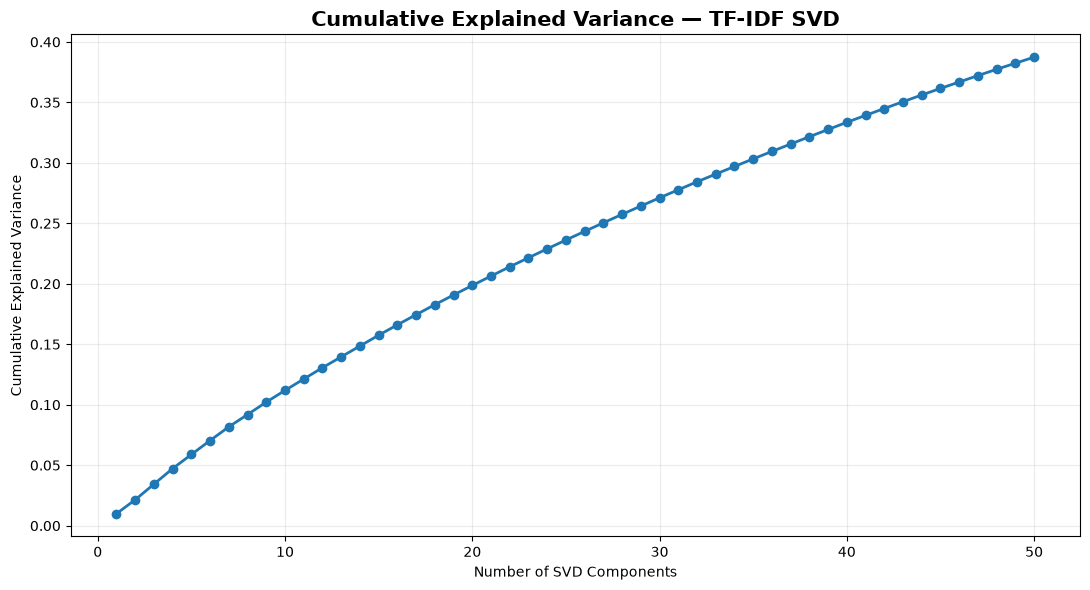

Saved figure: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_figures\tfidf_explained_variance.png


In [12]:
# ============================================================
# TF-IDF EMBEDDING DIAGNOSTICS
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)

components_to_plot = np.arange(
    1,
    len(cumulative_variance) + 1
)

ax.plot(
    components_to_plot,
    cumulative_variance,
    marker="o",
    linewidth=2
)

ax.set_title(
    "Cumulative Explained Variance — TF-IDF SVD",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Number of SVD Components"
)

ax.set_ylabel(
    "Cumulative Explained Variance"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

figure_path = (
    NLP_FIGURE_DIR
    / "tfidf_explained_variance.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure_path}"
)

## 4. Sentiment Intelligence

Sentiment is treated as one risk signal rather than as a definitive measure of supply-chain disruption. Negative language can indicate complaints, quality problems, service failures, or operational stress, but it is combined with domain-specific signals instead of being used alone.

In [13]:
# ============================================================
# SENTIMENT ANALYSIS
# ============================================================

POSITIVE_TERMS = [
    "excellent",
    "good",
    "great",
    "reliable",
    "satisfied",
    "quality",
    "fast",
    "efficient",
    "available",
    "successful",
]

NEGATIVE_TERMS = [
    "bad",
    "poor",
    "problem",
    "issue",
    "failure",
    "failed",
    "delay",
    "damaged",
    "shortage",
    "complaint",
    "unreliable",
    "critical",
    "severe",
    "fake",
    "counterfeit",
]


def fallback_sentiment(
    text: str
) -> float:

    if not text:
        return 0.0

    positive = count_lexicon_terms(
        text,
        POSITIVE_TERMS
    )

    negative = count_lexicon_terms(
        text,
        NEGATIVE_TERMS
    )

    total = (
        positive
        +
        negative
    )

    if total == 0:
        return 0.0

    return (
        positive - negative
    ) / total


def calculate_sentiment(
    text: str
) -> float:

    if not text:
        return 0.0

    if VADER_AVAILABLE:

        return sentiment_analyzer.polarity_scores(
            text
        )["compound"]

    return fallback_sentiment(
        text
    )


df["nlp_sentiment_compound"] = (
    df["nlp_document"]
    .apply(
        calculate_sentiment
    )
)

df["nlp_negative_sentiment_score"] = (
    (
        1
        -
        df["nlp_sentiment_compound"]
    )
    / 2
).clip(
    0,
    1
)

def sentiment_label(
    score: float
) -> str:

    if score >= 0.05:
        return "POSITIVE"

    if score <= -0.05:
        return "NEGATIVE"

    return "NEUTRAL"


df["nlp_sentiment_label"] = (
    df["nlp_sentiment_compound"]
    .apply(
        sentiment_label
    )
)

print("=" * 80)
print("SENTIMENT ANALYSIS COMPLETE")
print("=" * 80)

sentiment_distribution = (
    df["nlp_sentiment_label"]
    .value_counts()
    .rename_axis("sentiment")
    .reset_index(
        name="record_count"
    )
)

sentiment_distribution[
    "percentage"
] = (
    sentiment_distribution[
        "record_count"
    ]
    / len(df)
    * 100
).round(2)

display(
    sentiment_distribution
)

display(
    df[
        [
            "record_id",
            "nlp_sentiment_compound",
            "nlp_sentiment_label",
            "nlp_negative_sentiment_score"
        ]
    ].head(15)
)

SENTIMENT ANALYSIS COMPLETE


,sentiment,record_count,percentage
0,NEUTRAL,174,57.4300
1,POSITIVE,79,26.0700
2,NEGATIVE,50,16.5000


,record_id,nlp_sentiment_compound,nlp_sentiment_label,nlp_negative_sentiment_score
0,SS-000001,0.0000,NEUTRAL,0.5000
1,SS-000002,0.0000,NEUTRAL,0.5000
2,SS-000003,-0.5859,NEGATIVE,0.7930
3,SS-000004,0.1531,POSITIVE,0.4234
4,SS-000005,0.6808,POSITIVE,0.1596
5,SS-000006,-0.5859,NEGATIVE,0.7930
6,SS-000007,0.0000,NEUTRAL,0.5000
7,SS-000008,0.0000,NEUTRAL,0.5000
8,SS-000009,0.0000,NEUTRAL,0.5000
9,SS-000010,0.6808,POSITIVE,0.1596


In [14]:
# ============================================================
# TEXT INTENSITY FEATURES
# ============================================================

df["nlp_exclamation_count"] = (
    df["nlp_document"]
    .str.count(r"!")
)

df["nlp_question_count"] = (
    df["nlp_document"]
    .str.count(r"\?")
)

df["nlp_numeric_token_count"] = (
    df["nlp_document"]
    .str.count(
        r"\b\d+(?:\.\d+)?\b"
    )
)

df["nlp_uppercase_ratio"] = (
    df["nlp_document"]
    .apply(
        lambda text: (
            sum(
                character.isupper()
                for character in text
            )
            /
            max(
                sum(
                    character.isalpha()
                    for character in text
                ),
                1
            )
        )
    )
)

df["nlp_urgency_score"] = (
    np.clip(
        df["nlp_urgency_count"] / 2,
        0,
        1
    )
)

df["nlp_disruption_score"] = (
    np.clip(
        (
            df["nlp_supply_disruption_count"]
            +
            df["nlp_production_disruption_count"]
            +
            df["nlp_logistics_disruption_count"]
        )
        / 3,
        0,
        1
    )
)

df["nlp_supplier_risk_score"] = (
    np.clip(
        df["nlp_supplier_risk_count"] / 2,
        0,
        1
    )
)

df["nlp_quality_risk_score"] = (
    np.clip(
        df["nlp_quality_risk_count"] / 2,
        0,
        1
    )
)

df["nlp_counterfeit_risk_score"] = (
    np.clip(
        df["nlp_counterfeit_risk_count"] / 2,
        0,
        1
    )
)

df["nlp_price_pressure_score"] = (
    np.clip(
        df["nlp_price_pressure_count"] / 2,
        0,
        1
    )
)

print("=" * 80)
print("TEXT INTENSITY FEATURES GENERATED")
print("=" * 80)

display(
    df[
        [
            "record_id",
            "nlp_disruption_score",
            "nlp_supplier_risk_score",
            "nlp_quality_risk_score",
            "nlp_counterfeit_risk_score",
            "nlp_price_pressure_score",
            "nlp_urgency_score"
        ]
    ].head(15)
)

TEXT INTENSITY FEATURES GENERATED


,record_id,nlp_disruption_score,nlp_supplier_risk_score,nlp_quality_risk_score,nlp_counterfeit_risk_score,nlp_price_pressure_score,nlp_urgency_score
0,SS-000001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,SS-000002,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,SS-000003,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,SS-000004,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,SS-000005,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,SS-000006,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,SS-000007,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,SS-000008,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,SS-000009,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
9,SS-000010,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [15]:
# ============================================================
# NLP COMPOSITE RISK SCORE
# ============================================================

# ------------------------------------------------------------
# Explainable weighted NLP risk model
# ------------------------------------------------------------
#
# The weights represent the importance of domain signals,
# not trained model coefficients.
#
# They will later be integrated with ML anomaly scores in
# 05_risk_scoring_engine.ipynb.
# ------------------------------------------------------------

NLP_WEIGHTS = {
    "disruption": 0.30,
    "supplier": 0.15,
    "quality": 0.10,
    "counterfeit": 0.10,
    "price_pressure": 0.10,
    "negative_sentiment": 0.10,
    "urgency": 0.15,
}

df["nlp_risk_score"] = (
    NLP_WEIGHTS["disruption"]
    * df["nlp_disruption_score"]

    +

    NLP_WEIGHTS["supplier"]
    * df["nlp_supplier_risk_score"]

    +

    NLP_WEIGHTS["quality"]
    * df["nlp_quality_risk_score"]

    +

    NLP_WEIGHTS["counterfeit"]
    * df["nlp_counterfeit_risk_score"]

    +

    NLP_WEIGHTS["price_pressure"]
    * df["nlp_price_pressure_score"]

    +

    NLP_WEIGHTS["negative_sentiment"]
    * df["nlp_negative_sentiment_score"]

    +

    NLP_WEIGHTS["urgency"]
    * df["nlp_urgency_score"]
)

df["nlp_risk_score"] = (
    df["nlp_risk_score"]
    .clip(
        0,
        1
    )
)

df["nlp_risk_score_100"] = (
    df["nlp_risk_score"]
    * 100
).round(2)


def classify_nlp_risk(
    score: float
) -> str:

    if score >= 0.80:
        return "CRITICAL"

    if score >= 0.60:
        return "HIGH"

    if score >= 0.35:
        return "MEDIUM"

    if score >= 0.15:
        return "LOW"

    return "MINIMAL"


df["nlp_risk_band"] = (
    df["nlp_risk_score"]
    .apply(
        classify_nlp_risk
    )
)

print("=" * 80)
print("NLP RISK ENGINE COMPLETE")
print("=" * 80)

display(
    df[
        [
            "record_id",
            "nlp_primary_risk_category",
            "nlp_sentiment_label",
            "nlp_risk_score_100",
            "nlp_risk_band"
        ]
    ]
    .sort_values(
        "nlp_risk_score_100",
        ascending=False
    )
    .head(25)
)

NLP RISK ENGINE COMPLETE


,record_id,nlp_primary_risk_category,nlp_sentiment_label,nlp_risk_score_100,nlp_risk_band
301,SS-000302,NORMAL,NEGATIVE,9.7900,MINIMAL
42,SS-000043,NORMAL,NEGATIVE,8.9800,MINIMAL
186,SS-000187,NORMAL,NEGATIVE,8.7900,MINIMAL
167,SS-000168,NORMAL,NEGATIVE,8.6800,MINIMAL
135,SS-000136,NORMAL,NEGATIVE,8.6800,MINIMAL
200,SS-000201,NORMAL,NEGATIVE,8.6800,MINIMAL
182,SS-000183,NORMAL,NEGATIVE,8.4500,MINIMAL
143,SS-000144,NORMAL,NEGATIVE,8.4000,MINIMAL
274,SS-000275,NORMAL,NEGATIVE,7.9300,MINIMAL
10,SS-000011,NORMAL,NEGATIVE,7.9300,MINIMAL


In [16]:
# ============================================================
# EXPLAINABLE NLP RISK REASONS
# ============================================================

def generate_nlp_reasons(
    row: pd.Series
) -> str:

    reasons = []

    if row.get(
        "nlp_supply_disruption_count",
        0
    ) > 0:

        reasons.append(
            "supply disruption language detected"
        )

    if row.get(
        "nlp_production_disruption_count",
        0
    ) > 0:

        reasons.append(
            "production disruption language detected"
        )

    if row.get(
        "nlp_logistics_disruption_count",
        0
    ) > 0:

        reasons.append(
            "logistics disruption language detected"
        )

    if row.get(
        "nlp_supplier_risk_count",
        0
    ) > 0:

        reasons.append(
            "supplier risk language detected"
        )

    if row.get(
        "nlp_quality_risk_count",
        0
    ) > 0:

        reasons.append(
            "quality risk language detected"
        )

    if row.get(
        "nlp_counterfeit_risk_count",
        0
    ) > 0:

        reasons.append(
            "counterfeit-related language detected"
        )

    if row.get(
        "nlp_price_pressure_count",
        0
    ) > 0:

        reasons.append(
            "price pressure language detected"
        )

    if row.get(
        "nlp_urgency_count",
        0
    ) > 0:

        reasons.append(
            "urgent or critical language detected"
        )

    if row.get(
        "nlp_sentiment_label",
        "NEUTRAL"
    ) == "NEGATIVE":

        reasons.append(
            "negative sentiment detected"
        )

    if not reasons:

        reasons.append(
            "no strong domain-specific textual risk signal"
        )

    return "; ".join(
        reasons
    )


df["nlp_risk_reasons"] = (
    df.apply(
        generate_nlp_reasons,
        axis=1
    )
)

display(
    df[
        [
            "record_id",
            "nlp_risk_score_100",
            "nlp_risk_band",
            "nlp_risk_reasons"
        ]
    ]
    .sort_values(
        "nlp_risk_score_100",
        ascending=False
    )
    .head(25)
)

,record_id,nlp_risk_score_100,nlp_risk_band,nlp_risk_reasons
301,SS-000302,9.7900,MINIMAL,negative sentiment detected
42,SS-000043,8.9800,MINIMAL,negative sentiment detected
186,SS-000187,8.7900,MINIMAL,negative sentiment detected
167,SS-000168,8.6800,MINIMAL,negative sentiment detected
135,SS-000136,8.6800,MINIMAL,negative sentiment detected
200,SS-000201,8.6800,MINIMAL,negative sentiment detected
182,SS-000183,8.4500,MINIMAL,negative sentiment detected
143,SS-000144,8.4000,MINIMAL,negative sentiment detected
274,SS-000275,7.9300,MINIMAL,negative sentiment detected
10,SS-000011,7.9300,MINIMAL,negative sentiment detected


## 5. NLP and ML Anomaly Agreement

NLP risk and statistical anomaly detection answer different questions.

- Isolation Forest asks whether the overall numerical/structured behaviour is unusual.
- NLP asks whether the textual evidence contains meaningful risk signals.

Their agreement is therefore a useful prioritization signal, but not proof of an actual disruption.

In [17]:
# ============================================================
# NLP + ML SIGNAL AGREEMENT
# ============================================================

df["ml_nlp_signal_gap"] = (
    np.abs(
        df["ml_anomaly_score"]
        -
        df["nlp_risk_score"]
    )
)

df["ml_nlp_combined_signal"] = (
    0.55 * df["ml_anomaly_score"]
    +
    0.45 * df["nlp_risk_score"]
).clip(
    0,
    1
)

df["ml_nlp_combined_score_100"] = (
    df["ml_nlp_combined_signal"]
    * 100
).round(2)


def classify_combined_signal(
    row: pd.Series
) -> str:

    ml_score = row[
        "ml_anomaly_score"
    ]

    nlp_score = row[
        "nlp_risk_score"
    ]

    combined = row[
        "ml_nlp_combined_signal"
    ]

    if (
        ml_score >= 0.70
        and nlp_score >= 0.60
    ):
        return "HIGH_CONFIDENCE_RISK_SIGNAL"

    if (
        ml_score >= 0.70
        or nlp_score >= 0.60
    ):
        return "REVIEW_REQUIRED"

    if combined >= 0.35:
        return "MONITOR"

    return "LOW_PRIORITY"


df["ml_nlp_signal_status"] = (
    df.apply(
        classify_combined_signal,
        axis=1
    )
)

print("=" * 80)
print("ML + NLP SIGNAL AGREEMENT")
print("=" * 80)

signal_distribution = (
    df["ml_nlp_signal_status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(
        name="record_count"
    )
)

signal_distribution[
    "percentage"
] = (
    signal_distribution[
        "record_count"
    ]
    / len(df)
    * 100
).round(2)

display(
    signal_distribution
)

display(
    df[
        [
            "record_id",
            "ml_anomaly_score",
            "nlp_risk_score",
            "ml_nlp_combined_score_100",
            "ml_nlp_signal_status"
        ]
    ]
    .sort_values(
        "ml_nlp_combined_score_100",
        ascending=False
    )
    .head(25)
)

ML + NLP SIGNAL AGREEMENT


,status,record_count,percentage
0,LOW_PRIORITY,271,89.4400
1,REVIEW_REQUIRED,21,6.9300
2,MONITOR,11,3.6300


,record_id,ml_anomaly_score,nlp_risk_score,ml_nlp_combined_score_100,ml_nlp_signal_status
5,SS-000006,0.9869,0.0793,57.8500,REVIEW_REQUIRED
127,SS-000128,1.0000,0.0500,57.2500,REVIEW_REQUIRED
99,SS-000100,0.9904,0.0613,57.2300,REVIEW_REQUIRED
238,SS-000239,0.9671,0.0500,55.4400,REVIEW_REQUIRED
8,SS-000009,0.8480,0.0500,48.8900,REVIEW_REQUIRED
167,SS-000168,0.8149,0.0868,48.7200,REVIEW_REQUIRED
11,SS-000012,0.8111,0.0793,48.1800,REVIEW_REQUIRED
2,SS-000003,0.8074,0.0793,47.9800,REVIEW_REQUIRED
4,SS-000005,0.8500,0.0160,47.4700,REVIEW_REQUIRED
42,SS-000043,0.7829,0.0898,47.1000,REVIEW_REQUIRED


,ml_anomaly_score,nlp_risk_score,nlp_disruption_score,nlp_supplier_risk_score,nlp_quality_risk_score,nlp_counterfeit_risk_score,nlp_price_pressure_score,nlp_urgency_score,nlp_negative_sentiment_score
ml_anomaly_score,1.0000,0.1454,NaN,NaN,NaN,NaN,-0.0661,NaN,0.1608
nlp_risk_score,0.1454,1.0000,NaN,NaN,NaN,NaN,0.1102,NaN,0.9717
nlp_disruption_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nlp_supplier_risk_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nlp_quality_risk_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nlp_counterfeit_risk_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nlp_price_pressure_score,-0.0661,0.1102,NaN,NaN,NaN,NaN,1.0000,NaN,-0.1279
nlp_urgency_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nlp_negative_sentiment_score,0.1608,0.9717,NaN,NaN,NaN,NaN,-0.1279,NaN,1.0000


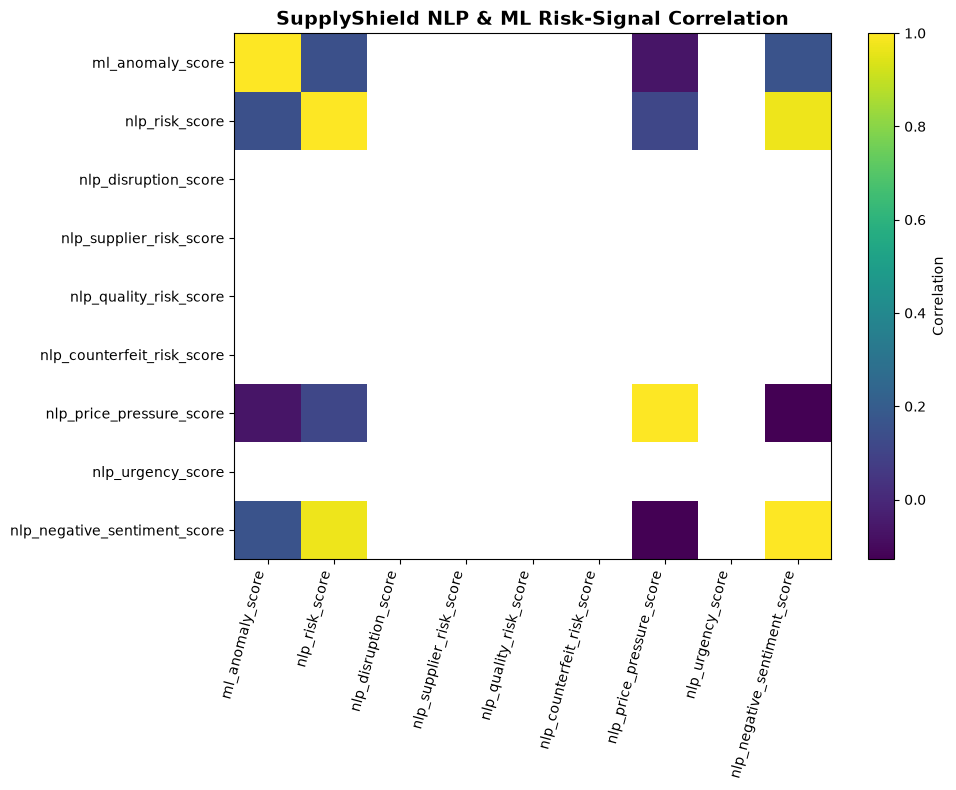

Saved figure: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_figures\nlp_ml_signal_correlation.png


In [18]:
# ============================================================
# RISK SIGNAL MATRIX
# ============================================================

signal_columns = [
    "ml_anomaly_score",
    "nlp_risk_score",
    "nlp_disruption_score",
    "nlp_supplier_risk_score",
    "nlp_quality_risk_score",
    "nlp_counterfeit_risk_score",
    "nlp_price_pressure_score",
    "nlp_urgency_score",
    "nlp_negative_sentiment_score",
]

signal_correlation = (
    df[signal_columns]
    .corr()
)

display(
    signal_correlation
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(
    signal_correlation,
    aspect="auto"
)

ax.set_xticks(
    range(len(signal_columns))
)

ax.set_yticks(
    range(len(signal_columns))
)

ax.set_xticklabels(
    signal_columns,
    rotation=75,
    ha="right"
)

ax.set_yticklabels(
    signal_columns
)

ax.set_title(
    "SupplyShield NLP & ML Risk-Signal Correlation",
    fontsize=14,
    fontweight="bold"
)

plt.colorbar(
    image,
    ax=ax,
    label="Correlation"
)

plt.tight_layout()

figure_path = (
    NLP_FIGURE_DIR
    / "nlp_ml_signal_correlation.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure_path}"
)

In [19]:
# ============================================================
# HIGH-PRIORITY NLP + ML RECORDS
# ============================================================

priority_columns = [
    "record_id",
    "source",
    "title",
    "company",
    "supplier",
    "product",
    "location",
    "ml_anomaly_score",
    "ml_anomaly_score_100",
    "nlp_risk_score",
    "nlp_risk_score_100",
    "nlp_primary_risk_category",
    "nlp_sentiment_label",
    "ml_nlp_combined_score_100",
    "ml_nlp_signal_status",
    "nlp_risk_reasons",
]

priority_columns = [
    column
    for column in priority_columns
    if column in df.columns
]

high_priority_records = (
    df[
        df[
            "ml_nlp_signal_status"
        ]
        ==
        "HIGH_CONFIDENCE_RISK_SIGNAL"
    ]
    .sort_values(
        "ml_nlp_combined_score_100",
        ascending=False
    )
)

print("=" * 80)
print("HIGH-CONFIDENCE NLP + ML RISK SIGNALS")
print("=" * 80)

print(
    f"Records identified: "
    f"{len(high_priority_records):,}"
)

display(
    high_priority_records[
        priority_columns
    ].head(30)
)

HIGH-CONFIDENCE NLP + ML RISK SIGNALS
Records identified: 0


,record_id,source,title,company,supplier,product,location,ml_anomaly_score,ml_anomaly_score_100,nlp_risk_score,nlp_risk_score_100,nlp_primary_risk_category,nlp_sentiment_label,ml_nlp_combined_score_100,ml_nlp_signal_status,nlp_risk_reasons


In [20]:
# ============================================================
# SUPPLIER NLP RISK PROFILING
# ============================================================

if "supplier" in df.columns:

    supplier_nlp_profile = (
        df
        .groupby(
            "supplier",
            dropna=False
        )
        .agg(
            records=(
                "record_id",
                "count"
            ),
            mean_nlp_risk=(
                "nlp_risk_score",
                "mean"
            ),
            maximum_nlp_risk=(
                "nlp_risk_score",
                "max"
            ),
            disruption_frequency=(
                "nlp_disruption_score",
                lambda x: (
                    x > 0
                ).mean()
            ),
            counterfeit_frequency=(
                "nlp_counterfeit_risk_score",
                lambda x: (
                    x > 0
                ).mean()
            ),
            negative_sentiment_frequency=(
                "nlp_sentiment_label",
                lambda x: (
                    x == "NEGATIVE"
                ).mean()
            ),
        )
        .reset_index()
    )

    supplier_nlp_profile[
        "mean_nlp_risk_100"
    ] = (
        supplier_nlp_profile[
            "mean_nlp_risk"
        ]
        * 100
    ).round(2)

    supplier_nlp_profile[
        "maximum_nlp_risk_100"
    ] = (
        supplier_nlp_profile[
            "maximum_nlp_risk"
        ]
        * 100
    ).round(2)

    supplier_nlp_profile[
        "disruption_frequency_pct"
    ] = (
        supplier_nlp_profile[
            "disruption_frequency"
        ]
        * 100
    ).round(2)

    supplier_nlp_profile[
        "counterfeit_frequency_pct"
    ] = (
        supplier_nlp_profile[
            "counterfeit_frequency"
        ]
        * 100
    ).round(2)

    supplier_nlp_profile[
        "negative_sentiment_frequency_pct"
    ] = (
        supplier_nlp_profile[
            "negative_sentiment_frequency"
        ]
        * 100
    ).round(2)

    supplier_nlp_profile = (
        supplier_nlp_profile
        .query(
            "records >= 2"
        )
        .sort_values(
            "mean_nlp_risk",
            ascending=False
        )
    )

    display(
        supplier_nlp_profile.head(25)
    )

else:

    supplier_nlp_profile = (
        pd.DataFrame()
    )

,supplier,records,mean_nlp_risk,maximum_nlp_risk,disruption_frequency,counterfeit_frequency,negative_sentiment_frequency,mean_nlp_risk_100,maximum_nlp_risk_100,disruption_frequency_pct,counterfeit_frequency_pct,negative_sentiment_frequency_pct
0,,303,0.0473,0.0979,0.0000,0.0000,0.1650,4.7300,9.7900,0.0000,0.0000,16.5000


## 6. NLP Model Artifacts and Explainable Outputs

The vectorizer and dimensionality-reduction model are persisted so the same text representation can be applied consistently to future scraped data. Structured NLP predictions are also saved for the downstream risk engine and dashboard.

In [21]:
# ============================================================
# SAVE NLP MODELS
# ============================================================

TFIDF_MODEL_PATH = (
    NLP_MODEL_DIR
    / "supplyshield_tfidf_vectorizer.joblib"
)

SVD_MODEL_PATH = (
    NLP_MODEL_DIR
    / "supplyshield_tfidf_svd.joblib"
)

joblib.dump(
    tfidf_vectorizer,
    TFIDF_MODEL_PATH
)

joblib.dump(
    tfidf_svd,
    SVD_MODEL_PATH
)

print("=" * 80)
print("NLP MODEL ARTIFACTS SAVED")
print("=" * 80)

print(
    "TF-IDF vectorizer:"
)

print(
    TFIDF_MODEL_PATH
)

print(
    "\nSVD model:"
)

print(
    SVD_MODEL_PATH
)

NLP MODEL ARTIFACTS SAVED
TF-IDF vectorizer:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_models\supplyshield_tfidf_vectorizer.joblib

SVD model:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_models\supplyshield_tfidf_svd.joblib


In [22]:
# ============================================================
# SAVE NLP RISK OUTPUTS
# ============================================================

NLP_OUTPUT_COLUMNS = [
    "record_id",
    "source",
    "title",
    "company",
    "supplier",
    "product",
    "event",
    "location",
    "availability",
    "review",

    # Text
    "nlp_document_length",
    "nlp_document_word_count",

    # Categories
    "nlp_primary_risk_category",

    # Sentiment
    "nlp_sentiment_compound",
    "nlp_sentiment_label",
    "nlp_negative_sentiment_score",

    # Domain risk
    "nlp_disruption_score",
    "nlp_supplier_risk_score",
    "nlp_quality_risk_score",
    "nlp_counterfeit_risk_score",
    "nlp_price_pressure_score",
    "nlp_urgency_score",

    # Composite NLP
    "nlp_risk_score",
    "nlp_risk_score_100",
    "nlp_risk_band",
    "nlp_risk_reasons",

    # ML + NLP
    "ml_anomaly_score",
    "ml_anomaly_score_100",
    "ml_anomaly_label",
    "anomaly_severity",
    "ml_nlp_signal_gap",
    "ml_nlp_combined_signal",
    "ml_nlp_combined_score_100",
    "ml_nlp_signal_status",
]

NLP_OUTPUT_COLUMNS = [
    column
    for column in NLP_OUTPUT_COLUMNS
    if column in df.columns
]

nlp_predictions = df[
    NLP_OUTPUT_COLUMNS
].copy()

NLP_PREDICTIONS_PATH = (
    NLP_OUTPUT_DIR
    / "nlp_risk_predictions.csv"
)

nlp_predictions.to_csv(
    NLP_PREDICTIONS_PATH,
    index=False,
    encoding="utf-8"
)

print(
    "=" * 80
)

print(
    "NLP PREDICTIONS SAVED"
)

print(
    "=" * 80
)

print(
    NLP_PREDICTIONS_PATH
)

print(
    f"\nRows saved: "
    f"{len(nlp_predictions):,}"
)

NLP PREDICTIONS SAVED
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_results\nlp_risk_predictions.csv

Rows saved: 303


In [23]:
# ============================================================
# SAVE NLP PIPELINE METADATA
# ============================================================

NLP_METADATA = {
    "project": "SupplyShield AI",
    "pipeline": "NLP Risk Engine",
    "random_state": RANDOM_STATE,

    "documents": int(
        len(df)
    ),

    "tfidf_dimensions": int(
        tfidf_matrix.shape[1]
    ),

    "svd_dimensions": int(
        n_components
    ),

    "tfidf_explained_variance": float(
        explained_variance.sum()
    ),

    "sentiment_engine":
        "VADER"
        if VADER_AVAILABLE
        else "domain_lexicon_fallback",

    "nlp_weights": NLP_WEIGHTS,

    "risk_categories": sorted(
        df[
            "nlp_primary_risk_category"
        ]
        .dropna()
        .unique()
        .tolist()
    ),

    "high_confidence_signal_count": int(
        (
            df[
                "ml_nlp_signal_status"
            ]
            ==
            "HIGH_CONFIDENCE_RISK_SIGNAL"
        ).sum()
    ),
}

NLP_METADATA_PATH = (
    NLP_OUTPUT_DIR
    / "nlp_pipeline_metadata.json"
)

with open(
    NLP_METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        NLP_METADATA,
        file,
        indent=4
    )

print(
    "Metadata saved:"
)

print(
    NLP_METADATA_PATH
)

Metadata saved:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_results\nlp_pipeline_metadata.json


In [24]:
# ============================================================
# SAVE NLP DIAGNOSTIC TABLES
# ============================================================

diagnostic_tables = {
    "nlp_category_distribution.csv":
        category_distribution,

    "nlp_sentiment_distribution.csv":
        sentiment_distribution,

    "nlp_signal_distribution.csv":
        signal_distribution,

    "tfidf_term_importance.csv":
        tfidf_term_importance,

    "nlp_ml_signal_correlation.csv":
        signal_correlation.reset_index(),
}

if not supplier_nlp_profile.empty:

    diagnostic_tables[
        "supplier_nlp_profile.csv"
    ] = supplier_nlp_profile


for filename, table in diagnostic_tables.items():

    output_path = (
        NLP_OUTPUT_DIR
        / filename
    )

    table.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved: {output_path}"
    )

Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_results\nlp_category_distribution.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_results\nlp_sentiment_distribution.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_results\nlp_signal_distribution.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_results\tfidf_term_importance.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_results\nlp_ml_signal_correlation.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_results\supplier_nlp_profile.csv


In [25]:
# ============================================================
# FINAL NLP PIPELINE VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("SUPPLYSHIELD AI — NLP PIPELINE VALIDATION")
print("=" * 80)

validation_checks = {

    "Dataset contains records":
        len(df) > 0,

    "NLP documents generated":
        df["nlp_document"].str.len().ge(0).all(),

    "TF-IDF matrix generated":
        tfidf_matrix.shape[0] == len(df),

    "TF-IDF vocabulary generated":
        tfidf_matrix.shape[1] > 0,

    "SVD embeddings generated":
        tfidf_embeddings.shape[0] == len(df),

    "Sentiment generated":
        "nlp_sentiment_compound" in df.columns,

    "NLP risk score generated":
        "nlp_risk_score" in df.columns,

    "NLP risk category generated":
        "nlp_primary_risk_category" in df.columns,

    "ML anomaly available":
        "ml_anomaly_score" in df.columns,

    "Combined ML + NLP signal generated":
        "ml_nlp_combined_signal" in df.columns,

    "NLP predictions saved":
        NLP_PREDICTIONS_PATH.exists(),

    "TF-IDF model saved":
        TFIDF_MODEL_PATH.exists(),

    "SVD model saved":
        SVD_MODEL_PATH.exists(),
}


for check, status in validation_checks.items():

    print(
        f"[{'PASS' if status else 'FAIL':<4}] "
        f"{check}"
    )


failed_checks = [
    check
    for check, status
    in validation_checks.items()
    if not status
]

print("-" * 80)

if failed_checks:

    print(
        "NLP PIPELINE VALIDATION FAILED"
    )

    for check in failed_checks:
        print(
            f" - {check}"
        )

    raise RuntimeError(
        "One or more NLP validation checks failed."
    )

else:

    print(
        "ALL NLP VALIDATION CHECKS PASSED."
    )

print("-" * 80)

print(
    f"Records analyzed       : {len(df):,}"
)

print(
    f"TF-IDF dimensions      : "
    f"{tfidf_matrix.shape[1]:,}"
)

print(
    f"NLP risk signals       : "
    f"{len(df):,}"
)

print(
    f"High-confidence ML+NLP : "
    f"{int((df['ml_nlp_signal_status'] == 'HIGH_CONFIDENCE_RISK_SIGNAL').sum()):,}"
)

print(
    f"\nOutput file:\n"
    f"{NLP_PREDICTIONS_PATH}"
)

print(
    "\nREADY FOR FINAL RISK SCORING ENGINE."
)


SUPPLYSHIELD AI — NLP PIPELINE VALIDATION
[PASS] Dataset contains records
[PASS] NLP documents generated
[PASS] TF-IDF matrix generated
[PASS] TF-IDF vocabulary generated
[PASS] SVD embeddings generated
[PASS] Sentiment generated
[PASS] NLP risk score generated
[PASS] NLP risk category generated
[PASS] ML anomaly available
[PASS] Combined ML + NLP signal generated
[PASS] NLP predictions saved
[PASS] TF-IDF model saved
[PASS] SVD model saved
--------------------------------------------------------------------------------
ALL NLP VALIDATION CHECKS PASSED.
--------------------------------------------------------------------------------
Records analyzed       : 303
TF-IDF dimensions      : 1,500
NLP risk signals       : 303
High-confidence ML+NLP : 0

Output file:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp_results\nlp_risk_predictions.csv

READY FOR FINAL RISK SCORING ENGINE.


## NLP Risk Engine Complete

The NLP layer now provides:

- Normalized supply-chain documents
- Domain-specific disruption detection
- Production and logistics risk signals
- Supplier risk signals
- Quality-risk signals
- Counterfeit-risk indicators
- Price-pressure indicators
- Urgency detection
- Sentiment analysis
- TF-IDF representations
- SVD text embeddings
- Explainable NLP risk scores
- NLP risk categories
- ML + NLP agreement signals
- Supplier NLP profiles
- Persisted NLP models and predictions

The next stage is the final SupplyShield risk-scoring engine, where these signals will be combined with availability, supplier, price, anomaly, and WebShield intelligence into a single explainable 0–100 risk score.

In [26]:
# ============================================================
# SUPPLYSHIELD AI
# SUPPLIER RISK SIGNAL ENGINE
# ============================================================
#
# Purpose:
# Generate a robust supplier-risk signal from available
# textual business intelligence fields.
#
# Design:
#   1. Automatically identifies the active dataframe.
#   2. Combines relevant text fields.
#   3. Detects supplier/disruption risk terminology.
#   4. Applies weighted risk categories.
#   5. Generates normalized 0-1 and 0-100 scores.
#   6. Produces explainable risk reasons.
#
# This is a transparent baseline risk engine suitable for
# hackathon demonstration and later replacement/augmentation
# with a trained supervised NLP model.
# ============================================================

import re
import numpy as np
import pandas as pd

print("=" * 100)
print("SUPPLYSHIELD AI — SUPPLIER RISK SIGNAL ENGINE")
print("=" * 100)


# ------------------------------------------------------------
# 1. IDENTIFY ACTIVE DATAFRAME
# ------------------------------------------------------------

candidate_names = [
    "risk_df",
    "nlp_df",
    "feature_df",
    "df",
    "data",
    "dataset",
    "processed_df",
]

active_df = None
active_name = None

for name in candidate_names:

    if name in globals():

        candidate = globals()[name]

        if isinstance(candidate, pd.DataFrame):

            active_df = candidate.copy()
            active_name = name
            break


if active_df is None:

    dataframe_candidates = [
        (name, value)
        for name, value in globals().items()
        if isinstance(value, pd.DataFrame)
    ]

    if dataframe_candidates:

        active_name, active_df = max(
            dataframe_candidates,
            key=lambda item: len(item[1])
        )

        active_df = active_df.copy()


if active_df is None:

    raise RuntimeError(
        "No pandas DataFrame was found in the notebook. "
        "Run the previous data/NLP preparation cells first."
    )


print(f"\nActive dataframe : {active_name}")
print(f"Rows             : {len(active_df):,}")
print(f"Columns          : {len(active_df.columns):,}")


# ------------------------------------------------------------
# 2. IDENTIFY AVAILABLE TEXT FIELDS
# ------------------------------------------------------------

preferred_text_columns = [
    "title",
    "event",
    "review",
    "supplier",
    "company",
    "product",
    "source",
    "location",
]

text_columns = [
    column
    for column in preferred_text_columns
    if column in active_df.columns
]


print("\nText fields used:")
for column in text_columns:
    print(f"  ✓ {column}")


if not text_columns:

    raise RuntimeError(
        "No usable textual columns were found for supplier-risk NLP."
    )


# ------------------------------------------------------------
# 3. TEXT NORMALIZATION
# ------------------------------------------------------------

def normalize_text(value):
    """
    Convert arbitrary input into normalized lowercase text.
    """
    
    if pd.isna(value):
        return ""

    text = str(value).lower()

    text = re.sub(
        r"[\r\n\t]+",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


for column in text_columns:

    active_df[f"_nlp_{column}"] = (
        active_df[column]
        .apply(normalize_text)
    )


# ------------------------------------------------------------
# 4. BUSINESS RISK TAXONOMY
# ------------------------------------------------------------

risk_terms = {

    "supplier_failure": {
        "weight": 1.00,
        "patterns": [
            r"\bsupplier failure\b",
            r"\bsupplier failed\b",
            r"\bsupplier collapse\b",
            r"\bsupplier bankruptcy\b",
            r"\bsupplier bankrupt\b",
            r"\bvendor failure\b",
            r"\bvendor bankrupt\b",
            r"\bvendor collapse\b",
            r"\bsupplier insolvency\b",
            r"\bvendor insolvency\b",
        ],
    },

    "delivery_disruption": {
        "weight": 0.90,
        "patterns": [
            r"\bdelivery delay\b",
            r"\bdelivery delayed\b",
            r"\blate delivery\b",
            r"\bshipment delay\b",
            r"\bshipping delay\b",
            r"\bdelayed shipment\b",
            r"\bdelayed delivery\b",
            r"\btransport disruption\b",
            r"\blogistics disruption\b",
            r"\bshipping disruption\b",
        ],
    },

    "shortage": {
        "weight": 0.95,
        "patterns": [
            r"\bsupply shortage\b",
            r"\bmaterial shortage\b",
            r"\bcomponent shortage\b",
            r"\braw material shortage\b",
            r"\bstock shortage\b",
            r"\bshortage\b",
            r"\bsupply constraint\b",
            r"\bsupply constraints\b",
            r"\blimited supply\b",
        ],
    },

    "production_disruption": {
        "weight": 1.00,
        "patterns": [
            r"\bfactory shutdown\b",
            r"\bplant shutdown\b",
            r"\bproduction shutdown\b",
            r"\bproduction halt\b",
            r"\bproduction halted\b",
            r"\bfactory closure\b",
            r"\bplant closure\b",
            r"\bmanufacturing disruption\b",
            r"\bproduction disruption\b",
        ],
    },

    "industrial_disruption": {
        "weight": 0.85,
        "patterns": [
            r"\bstrike\b",
            r"\blabor strike\b",
            r"\bworker strike\b",
            r"\bindustrial action\b",
            r"\blabor dispute\b",
            r"\blabour dispute\b",
            r"\bworker shortage\b",
        ],
    },

    "quality_failure": {
        "weight": 0.75,
        "patterns": [
            r"\bquality issue\b",
            r"\bquality problem\b",
            r"\bquality failure\b",
            r"\bdefective\b",
            r"\bdefect\b",
            r"\bmanufacturing defect\b",
            r"\bproduct defect\b",
            r"\bfailed quality\b",
            r"\bquality complaint\b",
        ],
    },

    "recall": {
        "weight": 0.95,
        "patterns": [
            r"\bproduct recall\b",
            r"\brecall\b",
            r"\brecall issued\b",
            r"\bsafety recall\b",
            r"\bmandatory recall\b",
        ],
    },

    "financial_risk": {
        "weight": 0.95,
        "patterns": [
            r"\bfinancial distress\b",
            r"\bfinancial trouble\b",
            r"\bcash flow problem\b",
            r"\bliquidity problem\b",
            r"\bdebt crisis\b",
            r"\bcredit risk\b",
            r"\bdefault\b",
            r"\binsolvent\b",
            r"\binsolvency\b",
        ],
    },

    "geopolitical_risk": {
        "weight": 0.80,
        "patterns": [
            r"\bsanction\b",
            r"\bsanctions\b",
            r"\btrade restriction\b",
            r"\btrade restrictions\b",
            r"\bexport restriction\b",
            r"\bimport restriction\b",
            r"\bgeopolitical tension\b",
            r"\bgeopolitical risk\b",
            r"\btrade war\b",
        ],
    },

    "natural_disaster": {
        "weight": 0.90,
        "patterns": [
            r"\bflood\b",
            r"\bflooding\b",
            r"\bearthquake\b",
            r"\bcyclone\b",
            r"\bhurricane\b",
            r"\btyphoon\b",
            r"\bwildfire\b",
            r"\bstorm\b",
            r"\bnatural disaster\b",
        ],
    },

    "cyber_security": {
        "weight": 0.90,
        "patterns": [
            r"\bcyberattack\b",
            r"\bcyber attack\b",
            r"\bransomware\b",
            r"\bdata breach\b",
            r"\bsecurity breach\b",
            r"\bcyber incident\b",
            r"\bhacked\b",
            r"\bmalware\b",
        ],
    },

    "fraud": {
        "weight": 1.00,
        "patterns": [
            r"\bfraud\b",
            r"\bfraudulent\b",
            r"\bscam\b",
            r"\bscam supplier\b",
            r"\bfake supplier\b",
            r"\bfake vendor\b",
        ],
    },

    "counterfeit": {
        "weight": 0.95,
        "patterns": [
            r"\bcounterfeit\b",
            r"\bfake product\b",
            r"\bfake products\b",
            r"\bauthenticity issue\b",
            r"\bforged\b",
        ],
    },

    "price_pressure": {
        "weight": 0.55,
        "patterns": [
            r"\bprice increase\b",
            r"\bprice increased\b",
            r"\bcost increase\b",
            r"\bcost increased\b",
            r"\braw material cost\b",
            r"\bmaterial costs\b",
            r"\bcost pressure\b",
            r"\bpricing pressure\b",
        ],
    },
}


# ------------------------------------------------------------
# 5. COMPILE REGEX PATTERNS
# ------------------------------------------------------------

compiled_terms = {}

for category, config in risk_terms.items():

    compiled_terms[category] = [
        re.compile(pattern, flags=re.IGNORECASE)
        for pattern in config["patterns"]
    ]


# ------------------------------------------------------------
# 6. RECORD-LEVEL SUPPLIER RISK ANALYSIS
# ------------------------------------------------------------

def calculate_supplier_risk(row):
    """
    Generate an explainable supplier-risk score.

    Returns:
        score_0_1
        matched_categories
        matched_terms
    """

    combined_text_parts = []

    # Give more importance to business-event fields.
    weighted_fields = [
        "title",
        "event",
        "review",
        "supplier",
        "company",
        "product",
        "source",
        "location",
    ]

    for field in weighted_fields:

        normalized_column = f"_nlp_{field}"

        if normalized_column in row.index:

            value = row[normalized_column]

            if value:
                combined_text_parts.append(
                    str(value)
                )

    text = " ".join(
        combined_text_parts
    )

    if not text.strip():

        return 0.0, [], []


    category_scores = {}
    matched_terms = []


    for category, patterns in compiled_terms.items():

        matches = []

        for pattern in patterns:

            found = pattern.findall(text)

            if found:
                matches.extend(found)

        if matches:

            category_scores[category] = risk_terms[
                category
            ]["weight"]

            matched_terms.extend(
                list(set(matches))
            )


    if not category_scores:

        return 0.0, [], []


    # --------------------------------------------------------
    # Evidence aggregation
    # --------------------------------------------------------

    # Multiple independent risk categories should increase
    # confidence, but we cap the score at 1.0.
    raw_score = sum(
        category_scores.values()
    )

    # Saturating normalization prevents excessive inflation
    # when many keywords occur in the same record.
    score = 1.0 - np.exp(
        -raw_score / 2.5
    )

    score = float(
        np.clip(
            score,
            0.0,
            1.0
        )
    )

    return (
        score,
        sorted(category_scores.keys()),
        sorted(set(matched_terms))
    )


# ------------------------------------------------------------
# 7. APPLY SUPPLIER RISK ENGINE
# ------------------------------------------------------------

supplier_results = active_df.apply(
    calculate_supplier_risk,
    axis=1,
    result_type="expand"
)

supplier_results.columns = [
    "nlp_supplier_risk_score",
    "nlp_supplier_risk_categories",
    "nlp_supplier_risk_terms",
]


active_df[
    [
        "nlp_supplier_risk_score",
        "nlp_supplier_risk_categories",
        "nlp_supplier_risk_terms",
    ]
] = supplier_results


# ------------------------------------------------------------
# 8. CREATE NORMALIZED 0-100 SCORE
# ------------------------------------------------------------

active_df["nlp_supplier_risk_score_100"] = (
    active_df["nlp_supplier_risk_score"]
    .mul(100)
    .round(2)
)


# ------------------------------------------------------------
# 9. HUMAN-READABLE RISK BAND
# ------------------------------------------------------------

def supplier_risk_band(score):

    if score < 20:
        return "LOW"

    elif score < 50:
        return "MODERATE"

    elif score < 75:
        return "HIGH"

    return "CRITICAL"


active_df["nlp_supplier_risk_band"] = (
    active_df["nlp_supplier_risk_score_100"]
    .apply(supplier_risk_band)
)


# ------------------------------------------------------------
# 10. EXPLAINABLE RISK REASONS
# ------------------------------------------------------------

def generate_supplier_risk_reason(row):

    categories = row.get(
        "nlp_supplier_risk_categories",
        []
    )

    if not categories:
        return "No supplier-risk signal detected."

    readable = [
        category.replace(
            "_",
            " "
        ).title()
        for category in categories
    ]

    return (
        "Detected: "
        + ", ".join(readable)
    )


active_df["nlp_supplier_risk_reason"] = (
    active_df.apply(
        generate_supplier_risk_reason,
        axis=1
    )
)


# ------------------------------------------------------------
# 11. UPDATE MAIN DATAFRAME
# ------------------------------------------------------------

if active_name in globals():

    globals()[active_name] = active_df

else:

    nlp_df = active_df


# ------------------------------------------------------------
# 12. DIAGNOSTIC SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("SUPPLIER RISK ENGINE SUMMARY")
print("=" * 100)

score_series = active_df[
    "nlp_supplier_risk_score_100"
]

print(
    f"\nTotal records             : {len(active_df):,}"
)

print(
    f"Non-zero supplier risk    : "
    f"{(score_series > 0).sum():,}"
)

print(
    f"Zero supplier risk        : "
    f"{(score_series == 0).sum():,}"
)

print(
    f"Mean supplier risk        : "
    f"{score_series.mean():.2f}"
)

print(
    f"Maximum supplier risk     : "
    f"{score_series.max():.2f}"
)


# ------------------------------------------------------------
# 13. RISK-BAND DISTRIBUTION
# ------------------------------------------------------------

print("\nSupplier risk bands:")
print(
    active_df[
        "nlp_supplier_risk_band"
    ].value_counts(
        dropna=False
    )
)


# ------------------------------------------------------------
# 14. TOP RISK RECORDS
# ------------------------------------------------------------

display_columns = [
    column
    for column in [
        "record_id",
        "source",
        "title",
        "supplier",
        "company",
        "event",
        "nlp_supplier_risk_score_100",
        "nlp_supplier_risk_band",
        "nlp_supplier_risk_reason",
        "nlp_supplier_risk_terms",
    ]
    if column in active_df.columns
]

print("\n" + "=" * 100)
print("TOP SUPPLIER-RISK RECORDS")
print("=" * 100)

display(
    active_df[
        display_columns
    ]
    .sort_values(
        "nlp_supplier_risk_score_100",
        ascending=False
    )
    .head(20)
)


print("\n" + "=" * 100)
print("SUPPLIER RISK ENGINE COMPLETED")
print("=" * 100)

SUPPLYSHIELD AI — SUPPLIER RISK SIGNAL ENGINE

Active dataframe : df
Rows             : 303
Columns          : 124

Text fields used:
  ✓ title
  ✓ event
  ✓ review
  ✓ supplier
  ✓ company
  ✓ product
  ✓ source
  ✓ location

SUPPLIER RISK ENGINE SUMMARY

Total records             : 303
Non-zero supplier risk    : 0
Zero supplier risk        : 303
Mean supplier risk        : 0.00
Maximum supplier risk     : 0.00

Supplier risk bands:
nlp_supplier_risk_band
LOW    303
Name: count, dtype: int64

TOP SUPPLIER-RISK RECORDS


,record_id,source,title,supplier,company,event,nlp_supplier_risk_score_100,nlp_supplier_risk_band,nlp_supplier_risk_reason,nlp_supplier_risk_terms
0,SS-000001,DeoDap,Wall Mount Mop Holder – No-Slide Grip for Home...,,GlimmerHome,,0.0000,LOW,No supplier-risk signal detected.,[]
1,SS-000002,DeoDap,Compact TianMu Tool Set – Essential 9-Piece Re...,,DeoDap,,0.0000,LOW,No supplier-risk signal detected.,[]
2,SS-000003,DeoDap,Manual Wall Fastening Nail Gun Tool Set (1 Set),,DeoDap,,0.0000,LOW,No supplier-risk signal detected.,[]
3,SS-000004,DeoDap,Mini Precision Screwdriver Set – Compact & Mul...,,DeoDap,,0.0000,LOW,No supplier-risk signal detected.,[]
4,SS-000005,DeoDap,Electric Drill Machine – Compact & Powerful 28...,,DeoDap,,0.0000,LOW,No supplier-risk signal detected.,[]
5,SS-000006,DeoDap,Leak Proof Tape – Instant Waterproof Seal for ...,,BoltForce,,0.0000,LOW,No supplier-risk signal detected.,[]
6,SS-000007,DeoDap,Metal Try Square Ruler Set – Durable 2-Piece P...,,DeoDap,,0.0000,LOW,No supplier-risk signal detected.,[]
7,SS-000008,DeoDap,Heavy Duty Sledge Hammer Rubber Mallet for Con...,,DeoDap,,0.0000,LOW,No supplier-risk signal detected.,[]
8,SS-000009,DeoDap,Hardware Tool Set – 11 Pcs Multi-Functional Ki...,,BoltForce,,0.0000,LOW,No supplier-risk signal detected.,[]
9,SS-000010,DeoDap,Heavy Duty Electric Drill – Powerful & Versati...,,DeoDap,,0.0000,LOW,No supplier-risk signal detected.,[]



SUPPLIER RISK ENGINE COMPLETED


In [27]:
# ============================================================
# SUPPLYSHIELD AI
# SUPPLIER RISK PROXY ENGINE
# ============================================================
#
# PURPOSE
# -------
# The current marketplace dataset does not contain reliable
# supplier-level information for every record.
#
# Therefore, this module calculates an explainable
# SUPPLIER RISK PROXY using observable business signals:
#
#   1. Price pressure
#   2. Rating weakness
#   3. Review/customer evidence
#   4. Availability concerns
#   5. Source uncertainty
#   6. Existing anomaly signals
#
# IMPORTANT
# ---------
# This is a proxy score and NOT a claim that a supplier is
# actually failing or fraudulent.
#
# When direct supplier/disruption intelligence becomes
# available from the web-intelligence layer, those signals
# can be incorporated into the final risk engine.
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import re
import numpy as np
import pandas as pd

from pathlib import Path


print("=" * 100)
print("SUPPLYSHIELD AI — SUPPLIER RISK PROXY ENGINE")
print("=" * 100)


# ============================================================
# 2. IDENTIFY THE ACTIVE DATAFRAME
# ============================================================

"""
The notebook may use different dataframe variable names
depending on which previous cells have been executed.

We therefore check the most likely dataframe names first.
"""

if "active_df" in globals() and isinstance(active_df, pd.DataFrame):

    proxy_df = active_df.copy()

elif "nlp_df" in globals() and isinstance(nlp_df, pd.DataFrame):

    proxy_df = nlp_df.copy()

elif "risk_df" in globals() and isinstance(risk_df, pd.DataFrame):

    proxy_df = risk_df.copy()

else:

    dataframe_candidates = [
        (name, value)
        for name, value in globals().items()
        if isinstance(value, pd.DataFrame)
    ]

    if not dataframe_candidates:

        raise RuntimeError(
            "No pandas DataFrame was found in the notebook. "
            "Please run the previous data/NLP preparation cells first."
        )

    # Select the largest available dataframe
    _, proxy_df = max(
        dataframe_candidates,
        key=lambda item: len(item[1])
    )

    proxy_df = proxy_df.copy()


print(f"\nRows    : {len(proxy_df):,}")
print(f"Columns : {len(proxy_df.columns):,}")


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def find_column(df, candidates):
    """
    Find the first matching dataframe column from a list
    of possible names.

    Matching is case-insensitive.
    """

    normalized_columns = {
        str(column).strip().lower(): column
        for column in df.columns
    }

    for candidate in candidates:

        candidate_key = (
            str(candidate)
            .strip()
            .lower()
        )

        if candidate_key in normalized_columns:

            return normalized_columns[candidate_key]

    return None


def numeric_series(df, column):
    """
    Safely convert a dataframe column to numeric values.
    """

    if column is None:

        return pd.Series(
            np.nan,
            index=df.index,
            dtype=float
        )

    return pd.to_numeric(
        df[column],
        errors="coerce"
    )


def minmax_normalize(series):
    """
    Normalize a numeric series between 0 and 1.

    Included as a reusable utility for later risk-engine
    development.
    """

    values = pd.to_numeric(
        series,
        errors="coerce"
    )

    if values.notna().sum() == 0:

        return pd.Series(
            0.0,
            index=series.index
        )

    minimum = values.min()
    maximum = values.max()

    if pd.isna(minimum) or pd.isna(maximum):

        return pd.Series(
            0.0,
            index=series.index
        )

    if maximum == minimum:

        return pd.Series(
            0.0,
            index=series.index
        )

    return (
        (values - minimum) /
        (maximum - minimum)
    ).fillna(0.0)


# ============================================================
# 4. IDENTIFY AVAILABLE BUSINESS SIGNAL COLUMNS
# ============================================================

price_col = find_column(
    proxy_df,
    [
        "price",
        "selling_price",
        "current_price",
        "amount"
    ]
)


rating_col = find_column(
    proxy_df,
    [
        "rating",
        "ratings",
        "review_rating",
        "star_rating"
    ]
)


review_col = find_column(
    proxy_df,
    [
        "review",
        "reviews",
        "review_count",
        "review_text"
    ]
)


availability_col = find_column(
    proxy_df,
    [
        "availability",
        "stock",
        "stock_status",
        "inventory"
    ]
)


source_col = find_column(
    proxy_df,
    [
        "source",
        "platform",
        "marketplace"
    ]
)


supplier_col = find_column(
    proxy_df,
    [
        "supplier",
        "vendor",
        "seller",
        "seller_name"
    ]
)


company_col = find_column(
    proxy_df,
    [
        "company",
        "manufacturer",
        "brand"
    ]
)


product_col = find_column(
    proxy_df,
    [
        "product",
        "product_name",
        "title"
    ]
)


print("\n" + "=" * 100)
print("AVAILABLE BUSINESS SIGNALS")
print("=" * 100)

print(f"Price        : {price_col}")
print(f"Rating       : {rating_col}")
print(f"Reviews      : {review_col}")
print(f"Availability : {availability_col}")
print(f"Source       : {source_col}")
print(f"Supplier     : {supplier_col}")
print(f"Company      : {company_col}")
print(f"Product      : {product_col}")


# ============================================================
# 5. PREPARE NUMERIC VARIABLES
# ============================================================

price = numeric_series(
    proxy_df,
    price_col
)


rating = numeric_series(
    proxy_df,
    rating_col
)


# ============================================================
# 6. PRICE PRESSURE SIGNAL
# ============================================================
#
# We use an IQR-based method to identify unusually high
# prices relative to the observed dataset.
#
# IQR method:
#
# Upper Threshold = Q3 + 1.5 × IQR
#
# The resulting signal is normalized to 0-1.
# ============================================================

if price.notna().sum() > 1:

    price_q25 = price.quantile(0.25)

    price_q75 = price.quantile(0.75)

    price_iqr = (
        price_q75 -
        price_q25
    )

    if price_iqr > 0:

        upper_price_threshold = (
            price_q75 +
            1.5 * price_iqr
        )

        denominator = (
            upper_price_threshold -
            price_q25
        )

        if denominator > 0:

            price_pressure = (
                (price - price_q25) /
                denominator
            )

            price_pressure = (
                price_pressure
                .clip(
                    lower=0,
                    upper=1
                )
                .fillna(0)
            )

        else:

            price_pressure = pd.Series(
                0.0,
                index=proxy_df.index
            )

    else:

        price_pressure = pd.Series(
            0.0,
            index=proxy_df.index
        )

else:

    price_pressure = pd.Series(
        0.0,
        index=proxy_df.index
    )


proxy_df["proxy_price_pressure"] = (
    price_pressure
)


# ============================================================
# 7. RATING RISK
# ============================================================
#
# Lower ratings indicate greater customer/business risk.
#
# Expected rating scale:
#
# 5.0 = minimum rating risk
# 0.0 = maximum rating risk
# ============================================================

if rating.notna().sum() > 0:

    rating_clipped = (
        rating
        .clip(
            lower=0,
            upper=5
        )
    )

    rating_risk = (
        1 -
        (
            rating_clipped /
            5
        )
    )

    rating_risk = (
        rating_risk
        .fillna(0)
        .clip(
            lower=0,
            upper=1
        )
    )

else:

    rating_risk = pd.Series(
        0.0,
        index=proxy_df.index
    )


proxy_df["proxy_rating_risk"] = (
    rating_risk
)


# ============================================================
# 8. REVIEW / CUSTOMER EVIDENCE SIGNAL
# ============================================================
#
# We search textual review information for operational and
# quality-risk indicators.
#
# This is intentionally conservative.
# ============================================================

review_risk = pd.Series(
    0.0,
    index=proxy_df.index
)


review_text_available = False


if review_col is not None:

    review_values = (
        proxy_df[review_col]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )

    review_text_available = (
        review_values.str.len() > 0
    ).any()


    negative_review_terms = [

        "bad",
        "poor",
        "worst",
        "defective",
        "defect",
        "broken",
        "damaged",
        "fake",
        "counterfeit",
        "fraud",
        "refund",
        "return",
        "complaint",
        "delay",
        "late",
        "missing",
        "unavailable",
        "problem",
        "issue"

    ]


    for term in negative_review_terms:

        term_matches = (
            review_values
            .str.contains(
                rf"\b{re.escape(term)}\b",
                regex=True,
                na=False
            )
            .astype(float)
        )

        review_risk = (
            review_risk +
            term_matches
        )


    review_risk = (
        review_risk
        .clip(
            lower=0,
            upper=5
        )
        / 5
    )


else:

    review_text_available = False


proxy_df["proxy_review_risk"] = (
    review_risk
)


# ============================================================
# 9. AVAILABILITY RISK
# ============================================================

availability_risk = pd.Series(
    0.0,
    index=proxy_df.index
)


if availability_col is not None:

    availability_values = (
        proxy_df[availability_col]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )


    availability_patterns = {

        "out_of_stock": 1.0,

        "out of stock": 1.0,

        "unavailable": 1.0,

        "not available": 1.0,

        "sold out": 1.0,

        "limited": 0.6,

        "low stock": 0.8,

        "few left": 0.8,

        "in stock": 0.0,

        "available": 0.0

    }


    for term, weight in availability_patterns.items():

        availability_risk = (
            availability_risk +

            (
                availability_values
                .str.contains(
                    re.escape(term),
                    regex=True,
                    na=False
                )
                .astype(float)
                * weight
            )
        )


    availability_risk = (
        availability_risk
        .clip(
            lower=0,
            upper=1
        )
    )


proxy_df["proxy_availability_risk"] = (
    availability_risk
)


# ============================================================
# 10. SOURCE UNCERTAINTY
# ============================================================
#
# Missing source information is treated as uncertainty,
# NOT as evidence of malicious activity.
#
# Therefore the maximum contribution is intentionally small.
# ============================================================

source_risk = pd.Series(
    0.0,
    index=proxy_df.index
)


if source_col is not None:

    source_values = (
        proxy_df[source_col]
        .fillna("unknown")
        .astype(str)
        .str.lower()
        .str.strip()
    )


    source_risk = pd.Series(
        np.where(
            source_values.isin(
                [
                    "",
                    "unknown",
                    "nan",
                    "none"
                ]
            ),
            0.20,
            0.0
        ),
        index=proxy_df.index,
        dtype=float
    )


proxy_df["proxy_source_uncertainty"] = (
    source_risk
)


# ============================================================
# 11. ANOMALY SIGNAL INTEGRATION
# ============================================================

anomaly_candidates = [

    "anomaly_score",

    "price_anomaly_score",

    "market_anomaly_score",

    "anomaly_risk_score",

    "ml_anomaly_score",

    "is_anomaly"

]


anomaly_col = find_column(
    proxy_df,
    anomaly_candidates
)


if anomaly_col is not None:

    anomaly_values = pd.to_numeric(
        proxy_df[anomaly_col],
        errors="coerce"
    ).fillna(0)


    anomaly_max = anomaly_values.max()


    if (
        anomaly_max > 1
        and anomaly_max <= 100
    ):

        anomaly_risk = (
            anomaly_values /
            100
        )


    else:

        anomaly_risk = (
            anomaly_values
            .clip(
                lower=0,
                upper=1
            )
        )


else:

    anomaly_risk = pd.Series(
        0.0,
        index=proxy_df.index
    )


proxy_df["proxy_anomaly_risk"] = (
    anomaly_risk
)


print(
    f"\nAnomaly signal column : {anomaly_col}"
)


# ============================================================
# 12. COMPOSITE SUPPLIER RISK PROXY
# ============================================================
#
# Weighted model
#
# Price pressure       20%
# Rating risk          20%
# Review risk          15%
# Availability risk    20%
# Source uncertainty    5%
# Anomaly risk         20%
#
# TOTAL                100%
# ============================================================

proxy_df["supplier_risk_proxy"] = (

    proxy_df["proxy_price_pressure"] * 0.20

    +

    proxy_df["proxy_rating_risk"] * 0.20

    +

    proxy_df["proxy_review_risk"] * 0.15

    +

    proxy_df["proxy_availability_risk"] * 0.20

    +

    proxy_df["proxy_source_uncertainty"] * 0.05

    +

    proxy_df["proxy_anomaly_risk"] * 0.20

)


proxy_df["supplier_risk_proxy"] = (
    proxy_df["supplier_risk_proxy"]
    .clip(
        lower=0,
        upper=1
    )
)


# ============================================================
# 13. SCALE TO 0-100
# ============================================================

proxy_df["supplier_risk_proxy_100"] = (

    proxy_df["supplier_risk_proxy"] * 100

).round(2)


# ============================================================
# 14. RISK BAND CLASSIFICATION
# ============================================================

def proxy_risk_band(score):

    if pd.isna(score):

        return "UNKNOWN"

    if score < 20:

        return "LOW"

    elif score < 50:

        return "MODERATE"

    elif score < 75:

        return "HIGH"

    else:

        return "CRITICAL"


proxy_df["supplier_risk_proxy_band"] = (

    proxy_df[
        "supplier_risk_proxy_100"
    ]
    .apply(proxy_risk_band)

)


# ============================================================
# 15. EXPLAINABLE RISK REASONS
# ============================================================

def build_proxy_reason(row):

    reasons = []


    if row["proxy_price_pressure"] >= 0.50:

        reasons.append(
            "elevated price pressure"
        )


    if row["proxy_rating_risk"] >= 0.50:

        reasons.append(
            "weak product rating"
        )


    if row["proxy_review_risk"] >= 0.40:

        reasons.append(
            "negative review evidence"
        )


    if row["proxy_availability_risk"] >= 0.50:

        reasons.append(
            "availability concern"
        )


    if row["proxy_anomaly_risk"] >= 0.50:

        reasons.append(
            "anomalous business signal"
        )


    if row["proxy_source_uncertainty"] > 0:

        reasons.append(
            "source uncertainty"
        )


    if not reasons:

        return (
            "No significant observable "
            "supplier-risk proxy signal."
        )


    return "; ".join(reasons)


proxy_df["supplier_risk_proxy_reason"] = (

    proxy_df.apply(
        build_proxy_reason,
        axis=1
    )

)


# ============================================================
# 16. COMPATIBILITY COLUMNS FOR DOWNSTREAM RISK ENGINE
# ============================================================
#
# Notebook 05 can consume these standardized fields.
# ============================================================

proxy_df["nlp_supplier_risk_score"] = (

    proxy_df["supplier_risk_proxy"]

)


proxy_df["nlp_supplier_risk_score_100"] = (

    proxy_df["supplier_risk_proxy_100"]

)


proxy_df["nlp_supplier_risk_band"] = (

    proxy_df["supplier_risk_proxy_band"]

)


proxy_df["nlp_supplier_risk_reason"] = (

    proxy_df["supplier_risk_proxy_reason"]

)


# ============================================================
# 17. UPDATE ACTIVE DATAFRAME
# ============================================================

active_df = proxy_df.copy()


# ============================================================
# 18. DIAGNOSTIC SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("SUPPLIER RISK PROXY SUMMARY")
print("=" * 100)


score = active_df[
    "supplier_risk_proxy_100"
]


print(
    f"\nTotal records          : {len(active_df):,}"
)


print(
    f"Non-zero proxy signals : "
    f"{(score > 0).sum():,}"
)


print(
    f"Zero proxy signals     : "
    f"{(score == 0).sum():,}"
)


print(
    f"Mean proxy risk        : "
    f"{score.mean():.2f}"
)


print(
    f"Median proxy risk      : "
    f"{score.median():.2f}"
)


print(
    f"Maximum proxy risk     : "
    f"{score.max():.2f}"
)


# ============================================================
# 19. RISK BAND DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("RISK BAND DISTRIBUTION")
print("=" * 100)


print(
    active_df[
        "supplier_risk_proxy_band"
    ]
    .value_counts(
        dropna=False
    )
)


# ============================================================
# 20. TOP 20 RISK RECORDS
# ============================================================

top_columns = [

    column

    for column in [

        "source",

        "title",

        "product",

        "company",

        "price",

        "rating",

        "availability",

        "supplier_risk_proxy_100",

        "supplier_risk_proxy_band",

        "supplier_risk_proxy_reason"

    ]

    if column in active_df.columns

]


print("\n" + "=" * 100)
print("TOP 20 SUPPLIER RISK PROXY RECORDS")
print("=" * 100)


display(

    active_df[
        top_columns
    ]
    .sort_values(
        by="supplier_risk_proxy_100",
        ascending=False
    )
    .head(20)

)


# ============================================================
# 21. FINAL VALIDATION
# ============================================================

required_proxy_columns = [

    "proxy_price_pressure",

    "proxy_rating_risk",

    "proxy_review_risk",

    "proxy_availability_risk",

    "proxy_source_uncertainty",

    "proxy_anomaly_risk",

    "supplier_risk_proxy",

    "supplier_risk_proxy_100",

    "supplier_risk_proxy_band",

    "supplier_risk_proxy_reason",

    "nlp_supplier_risk_score",

    "nlp_supplier_risk_score_100",

    "nlp_supplier_risk_band",

    "nlp_supplier_risk_reason"

]


missing_proxy_columns = [

    column

    for column in required_proxy_columns

    if column not in active_df.columns

]


if missing_proxy_columns:

    raise RuntimeError(
        "Supplier risk proxy validation failed. "
        f"Missing columns: {missing_proxy_columns}"
    )


print("\n" + "=" * 100)
print("VALIDATION PASSED")
print("=" * 100)

print(
    f"Generated proxy features : "
    f"{len(required_proxy_columns)}"
)

print(
    f"Final dataframe shape     : "
    f"{active_df.shape}"
)

print(
    "Supplier Risk Proxy Engine completed successfully."
)

print("=" * 100)

SUPPLYSHIELD AI — SUPPLIER RISK PROXY ENGINE

Rows    : 303
Columns : 137

AVAILABLE BUSINESS SIGNALS
Price        : price
Rating       : rating
Reviews      : review
Availability : availability
Source       : source
Supplier     : supplier
Company      : company
Product      : product

Anomaly signal column : ml_anomaly_score

SUPPLIER RISK PROXY SUMMARY

Total records          : 303
Non-zero proxy signals : 303
Zero proxy signals     : 0
Mean proxy risk        : 12.32
Median proxy risk      : 6.69
Maximum proxy risk     : 43.20

RISK BAND DISTRIBUTION
supplier_risk_proxy_band
LOW         233
MODERATE     70
Name: count, dtype: int64

TOP 20 SUPPLIER RISK PROXY RECORDS


,source,title,product,company,price,rating,availability,supplier_risk_proxy_100,supplier_risk_proxy_band,supplier_risk_proxy_reason
127,TradeIndia,Allenger Altima F100 Fixed Cath Lab Machine,Allenger Altima F100 Fixed Cath Lab Machine,Rentomed,"15,340,000.0000",4.2000,,43.2000,MODERATE,elevated price pressure; anomalous business si...
99,TradeIndia,Siemens Artis Zee Cath Lab - Application: Hosp...,Siemens Artis Zee Cath Lab,Arihant Medmach Private Limited,"14,000,000.0000",4.2000,,43.0100,MODERATE,elevated price pressure; anomalous business si...
238,TradeIndia,Cath Lab Machine,Cath Lab Machine,Mf India,"15,000,000.0000",4.2000,,42.5400,MODERATE,elevated price pressure; anomalous business si...
42,TradeIndia,Broken Bag Detector - Accuracy: +2 %,Broken Bag Detector,Applied Techno Engineers Private Limited,"58,000.0000",4.2000,,38.8600,MODERATE,elevated price pressure; anomalous business si...
200,TradeIndia,Broken Bag Detector - 315 Grade Stainless Stee...,Broken Bag Detector,Hnl Systems Pvt. Ltd.,"45,000.0000",4.2000,,38.7200,MODERATE,elevated price pressure; anomalous business si...
135,TradeIndia,10mm Broken Bag Detector - Frequency: 50hz,10mm Broken Bag Detector,Soarmlich Engineers,"35,231.0000",4.2000,,37.8800,MODERATE,elevated price pressure; anomalous business si...
218,TradeIndia,Front Belt 10 Bricks Making Machine - Feature:...,Front Belt 10 Bricks Making Machine,Kabir Industrial Technology,"1,200,000.0000",4.2000,,37.1000,MODERATE,elevated price pressure; anomalous business si...
102,TradeIndia,"Mini Dumper - Mild Steel Construction, Yellow ...",Mini Dumper,Vpg Buildwell India Pvt. Ltd.,"914,500.0000",4.2000,,35.5200,MODERATE,elevated price pressure; anomalous business si...
173,TradeIndia,"Multi Head Cnc Drill Machine - Metal, 2300mm X...",Multi Head Cnc Drill Machine,Mould Well,"550,000.0000",4.2000,,32.8900,MODERATE,elevated price pressure
73,TradeIndia,Air Slide - Color: Grey,Air Slide,Parul Engineering Private Limited,"40,000.0000",4.2000,,30.9800,MODERATE,elevated price pressure



VALIDATION PASSED
Generated proxy features : 14
Final dataframe shape     : (303, 147)
Supplier Risk Proxy Engine completed successfully.


In [30]:
# ============================================================
# SUPPLYSHIELD AI
# FINAL NLP DATASET EXPORT — PRODUCTION SAFE
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd


print("=" * 80)
print("SUPPLYSHIELD AI — FINAL NLP DATASET EXPORT")
print("=" * 80)


# ============================================================
# 1. LOCATE PROJECT ROOT
# ============================================================

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT != PROJECT_ROOT.parent:

    if (PROJECT_ROOT / "member2").exists():
        break

    PROJECT_ROOT = PROJECT_ROOT.parent


PROCESSED_DIR = (
    PROJECT_ROOT
    / "member2"
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("\nPROJECT ROOT")
print("-" * 80)
print(PROJECT_ROOT)

print("\nPROCESSED DIRECTORY")
print("-" * 80)
print(PROCESSED_DIR)


# ============================================================
# 2. DISCOVER DATAFRAMES AVAILABLE IN NOTEBOOK
# ============================================================

candidate_dataframes = {}

for variable_name, variable_value in list(globals().items()):

    if isinstance(variable_value, pd.DataFrame):

        candidate_dataframes[variable_name] = variable_value


print("\nDATAFRAMES AVAILABLE")
print("-" * 80)

if not candidate_dataframes:

    raise RuntimeError(
        "No pandas DataFrame was found in the notebook. "
        "Please run the NLP processing cells first."
    )


for name, dataframe in candidate_dataframes.items():

    print(
        f"{name:<40} "
        f"shape={dataframe.shape}"
    )


# ============================================================
# 3. IDENTIFY THE FINAL NLP DATAFRAME
# ============================================================

nlp_columns = {
    "nlp_supplier_risk_score",
    "nlp_risk_score",
    "nlp_risk_score_100",
    "nlp_sentiment_compound",
    "nlp_disruption_score"
}


best_dataframe = None
best_name = None
best_score = -1


for name, dataframe in candidate_dataframes.items():

    columns = set(dataframe.columns)

    score = 0

    # Strong NLP indicators
    score += (
        len(nlp_columns.intersection(columns))
        * 100
    )

    # Prefer expected dataset size
    if len(dataframe) == 303:
        score += 100

    # Prefer feature-engineered dataset
    if len(dataframe.columns) >= 100:
        score += 50

    # Prefer non-empty datasets
    if not dataframe.empty:
        score += 20


    if score > best_score:

        best_score = score
        best_dataframe = dataframe
        best_name = name


if best_dataframe is None:

    raise RuntimeError(
        "Unable to identify the final NLP dataframe."
    )


df_final = best_dataframe.copy()


print("\nSELECTED FINAL DATAFRAME")
print("-" * 80)
print(f"Variable name : {best_name}")
print(f"Shape         : {df_final.shape}")
print(f"Columns       : {len(df_final.columns)}")
print(f"Records       : {len(df_final)}")


# ============================================================
# 4. REMOVE ACCIDENTAL INDEX COLUMNS
# ============================================================

index_columns = [
    column
    for column in df_final.columns
    if str(column).lower().startswith("unnamed:")
]


if index_columns:

    print("\nRemoving accidental index columns:")

    for column in index_columns:
        print(f"  - {column}")

    df_final = df_final.drop(
        columns=index_columns
    )


# ============================================================
# 5. PRODUCTION-SAFE JSON SERIALIZER
# ============================================================

def make_json_safe(value):
    """
    Recursively convert pandas / NumPy / Python objects
    into JSON-compatible values.

    Handles:
        - NaN / NaT
        - NumPy integers
        - NumPy floats
        - NumPy booleans
        - NumPy arrays
        - Python lists
        - tuples
        - dictionaries
        - timestamps
    """

    # --------------------------------------------------------
    # None
    # --------------------------------------------------------

    if value is None:

        return None


    # --------------------------------------------------------
    # NumPy arrays
    # --------------------------------------------------------

    if isinstance(value, np.ndarray):

        return [
            make_json_safe(item)
            for item in value.tolist()
        ]


    # --------------------------------------------------------
    # Python lists / tuples / sets
    # --------------------------------------------------------

    if isinstance(
        value,
        (list, tuple, set)
    ):

        return [
            make_json_safe(item)
            for item in value
        ]


    # --------------------------------------------------------
    # Dictionaries
    # --------------------------------------------------------

    if isinstance(value, dict):

        return {
            str(key): make_json_safe(val)
            for key, val in value.items()
        }


    # --------------------------------------------------------
    # NumPy integers
    # --------------------------------------------------------

    if isinstance(
        value,
        np.integer
    ):

        return int(value)


    # --------------------------------------------------------
    # NumPy floating point values
    # --------------------------------------------------------

    if isinstance(
        value,
        np.floating
    ):

        if not np.isfinite(value):

            return None

        return float(value)


    # --------------------------------------------------------
    # NumPy boolean
    # --------------------------------------------------------

    if isinstance(
        value,
        np.bool_
    ):

        return bool(value)


    # --------------------------------------------------------
    # pandas timestamp
    # --------------------------------------------------------

    if isinstance(
        value,
        (pd.Timestamp, )
    ):

        if pd.isna(value):

            return None

        return value.isoformat()


    # --------------------------------------------------------
    # Python datetime-like objects
    # --------------------------------------------------------

    if hasattr(value, "isoformat") and not isinstance(
        value,
        (str, int, float, bool)
    ):

        try:

            return value.isoformat()

        except Exception:

            pass


    # --------------------------------------------------------
    # Standard Python float
    # --------------------------------------------------------

    if isinstance(value, float):

        if not np.isfinite(value):

            return None

        return value


    # --------------------------------------------------------
    # Standard Python primitive
    # --------------------------------------------------------

    if isinstance(
        value,
        (str, int, bool)
    ):

        return value


    # --------------------------------------------------------
    # pandas missing values
    # --------------------------------------------------------

    try:

        missing = pd.isna(value)

        # Only evaluate scalar missing values.
        # Arrays have already been handled above.

        if isinstance(
            missing,
            (bool, np.bool_)
        ):

            if bool(missing):

                return None

    except Exception:

        pass


    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    return str(value)


# ============================================================
# 6. CONVERT DATAFRAME TO JSON-SAFE RECORDS
# ============================================================

print("\nCONVERTING DATASET TO JSON-SAFE RECORDS...")
print("-" * 80)


records = []

for row_number, record in enumerate(
    df_final.to_dict(orient="records"),
    start=1
):

    safe_record = {}

    for column, value in record.items():

        safe_record[str(column)] = (
            make_json_safe(value)
        )

    records.append(safe_record)


print(
    f"Converted {len(records)} records successfully."
)


# ============================================================
# 7. DEFINE OUTPUT PATHS
# ============================================================

json_path = (
    PROCESSED_DIR
    / "unified_supply_data.json"
)

csv_path = (
    PROCESSED_DIR
    / "unified_supply_data.csv"
)

parquet_path = (
    PROCESSED_DIR
    / "unified_supply_data.parquet"
)


# ============================================================
# 8. EXPORT JSON — CANONICAL PIPELINE DATASET
# ============================================================

print("\nEXPORTING JSON")
print("-" * 80)

with open(
    json_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        records,
        file,
        ensure_ascii=False,
        indent=2,
        allow_nan=False
    )


print(
    f"JSON saved successfully:\n{json_path}"
)


# ============================================================
# 9. EXPORT CSV — INTEROPERABILITY FORMAT
# ============================================================

print("\nEXPORTING CSV")
print("-" * 80)

df_final.to_csv(
    csv_path,
    index=False,
    encoding="utf-8"
)


print(
    f"CSV saved successfully:\n{csv_path}"
)


# ============================================================
# 10. EXPORT PARQUET — ANALYTICS FORMAT
# ============================================================

print("\nEXPORTING PARQUET")
print("-" * 80)

try:

    df_final.to_parquet(
        parquet_path,
        index=False
    )

    print(
        f"Parquet saved successfully:\n"
        f"{parquet_path}"
    )

    parquet_status = True

except Exception as exc:

    parquet_status = False

    print(
        "Parquet export skipped."
    )

    print(
        f"Reason: {type(exc).__name__}: {exc}"
    )


# ============================================================
# 11. RELOAD JSON FOR INTEGRITY VALIDATION
# ============================================================

print("\nVALIDATING EXPORTED JSON")
print("-" * 80)

with open(
    json_path,
    "r",
    encoding="utf-8"
) as file:

    verification_records = json.load(file)


# ============================================================
# 12. RECORD COUNT VALIDATION
# ============================================================

if len(verification_records) != len(df_final):

    raise RuntimeError(
        "Record-count validation failed.\n"
        f"Expected: {len(df_final)}\n"
        f"Found:    {len(verification_records)}"
    )


# ============================================================
# 13. SCHEMA VALIDATION
# ============================================================

if verification_records:

    exported_columns = set(
        verification_records[0].keys()
    )

else:

    exported_columns = set()


original_columns = set(
    str(column)
    for column in df_final.columns
)


missing_columns = (
    original_columns
    - exported_columns
)


if missing_columns:

    raise RuntimeError(
        "Schema validation failed.\n"
        f"Missing columns: {missing_columns}"
    )


# ============================================================
# 14. REQUIRED NLP FEATURE VALIDATION
# ============================================================

print("\nREQUIRED NLP FEATURES")
print("-" * 80)

required_features = [
    "nlp_sentiment_compound",
    "nlp_negative_sentiment_score",
    "nlp_disruption_score",
    "nlp_supplier_risk_score",
    "nlp_quality_risk_score",
    "nlp_counterfeit_risk_score",
    "nlp_price_pressure_score",
    "nlp_urgency_score",
    "nlp_risk_score",
    "nlp_risk_score_100",
    "nlp_risk_band",
    "nlp_risk_reasons"
]


missing_features = []

for feature in required_features:

    if feature in df_final.columns:

        print(
            f"✓ {feature}"
        )

    else:

        print(
            f"✗ {feature}"
        )

        missing_features.append(feature)


# ============================================================
# 15. FINAL PIPELINE VALIDATION
# ============================================================

if missing_features:

    print("\nWARNING:")
    print(
        "Some optional/expected NLP features are missing:"
    )

    for feature in missing_features:

        print(
            f"  - {feature}"
        )


# ============================================================
# 16. FINAL EXPORT SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL EXPORT VALIDATION")
print("=" * 80)

print(
    f"Records exported        : {len(verification_records)}"
)

print(
    f"Columns exported        : {len(exported_columns)}"
)

print(
    f"Original dataframe shape : {df_final.shape}"
)

print(
    f"JSON file                : {json_path.exists()}"
)

print(
    f"CSV file                 : {csv_path.exists()}"
)

print(
    f"Parquet file             : {parquet_path.exists()}"
)


# File sizes

if json_path.exists():

    print(
        f"JSON size                : "
        f"{json_path.stat().st_size / 1024:.2f} KB"
    )


if csv_path.exists():

    print(
        f"CSV size                 : "
        f"{csv_path.stat().st_size / 1024:.2f} KB"
    )


if parquet_path.exists():

    print(
        f"Parquet size             : "
        f"{parquet_path.stat().st_size / 1024:.2f} KB"
    )


print("\n" + "=" * 80)
print("DATASET EXPORT COMPLETED SUCCESSFULLY")
print("=" * 80)

print(
    "\nThe canonical dataset is now ready for "
    "05_risk_scoring_engine.ipynb."
)

SUPPLYSHIELD AI — FINAL NLP DATASET EXPORT

PROJECT ROOT
--------------------------------------------------------------------------------
c:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI

PROCESSED DIRECTORY
--------------------------------------------------------------------------------
c:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\data\processed

DATAFRAMES AVAILABLE
--------------------------------------------------------------------------------
df                                       shape=(303, 137)
anomaly_df                               shape=(303, 19)
anomaly_subset                           shape=(303, 6)
text_quality                             shape=(8, 4)
category_distribution                    shape=(2, 3)
tfidf_term_importance                    shape=(1500, 2)
sentiment_distribution                   shape=(3, 3)
signal_distribution                      shape=(3, 3)
signal_correlation                       shape=(9, 9)
high_priority_reco

In [31]:
# ============================================================
# FINAL EXPORT — NLP RISK ENGINE → RISK SCORING ENGINE
# ============================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np

print("=" * 75)
print("SUPPLYSHIELD AI — EXPORTING NLP RISK ENGINE OUTPUT")
print("=" * 75)


# ------------------------------------------------------------
# 1. Identify the final dataframe
# ------------------------------------------------------------

candidate_dataframes = {}

for name, value in globals().items():

    if isinstance(value, pd.DataFrame):

        if len(value) > 0:
            candidate_dataframes[name] = value


if not candidate_dataframes:
    raise RuntimeError(
        "No non-empty DataFrame found in the NLP notebook."
    )


# Prefer the dataframe containing NLP/risk features
preferred_candidates = []

for name, dataframe in candidate_dataframes.items():

    columns_lower = {
        str(column).lower()
        for column in dataframe.columns
    }

    score = 0

    for required_feature in [
        "nlp_supplier_risk_score",
        "nlp_disruption_score",
        "nlp_negative_sentiment_score",
        "nlp_risk_score_100",
    ]:

        if required_feature.lower() in columns_lower:
            score += 1

    preferred_candidates.append(
        (score, len(dataframe), name, dataframe)
    )


preferred_candidates.sort(
    key=lambda item: (
        item[0],
        item[1]
    ),
    reverse=True
)


_, _, selected_dataframe_name, final_nlp_df = (
    preferred_candidates[0]
)


final_nlp_df = final_nlp_df.copy(deep=True)


print(f"\nSelected dataframe : {selected_dataframe_name}")
print(f"Rows               : {len(final_nlp_df):,}")
print(f"Columns            : {len(final_nlp_df.columns):,}")


# ------------------------------------------------------------
# 2. Create processed directory
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name.lower() != "member2":

    if PROJECT_ROOT.parent == PROJECT_ROOT:
        break

    PROJECT_ROOT = PROJECT_ROOT.parent


if PROJECT_ROOT.name.lower() != "member2":

    PROJECT_ROOT = (
        Path.cwd()
        / "member2"
    )


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. Normalize JSON-incompatible values
# ------------------------------------------------------------

def make_json_safe(value):

    if value is None:
        return None

    if value is pd.NA or value is pd.NaT:
        return None

    if isinstance(value, np.ndarray):
        return [
            make_json_safe(item)
            for item in value.tolist()
        ]

    if isinstance(value, (list, tuple)):
        return [
            make_json_safe(item)
            for item in value
        ]

    if isinstance(value, dict):

        return {
            str(key): make_json_safe(item)
            for key, item in value.items()
        }

    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):

        if np.isnan(value) or np.isinf(value):
            return None

        return float(value)

    if isinstance(value, float):

        if np.isnan(value) or np.isinf(value):
            return None

        return value

    return value


# ------------------------------------------------------------
# 4. Convert dataframe to JSON-safe records
# ------------------------------------------------------------

records = []

for record in final_nlp_df.to_dict(
    orient="records"
):

    records.append(
        {
            str(key): make_json_safe(value)
            for key, value in record.items()
        }
    )


# ------------------------------------------------------------
# 5. Export JSON
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR
    / "nlp_risk_engine_output.json"
)


with open(
    output_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        records,
        file,
        ensure_ascii=False,
        indent=2
    )


# ------------------------------------------------------------
# 6. Also export Parquet for production use
# ------------------------------------------------------------

parquet_path = (
    PROCESSED_DIR
    / "nlp_risk_engine_output.parquet"
)


try:

    final_nlp_df.to_parquet(
        parquet_path,
        index=False
    )

    parquet_status = "SUCCESS"

except Exception as exc:

    parquet_status = (
        f"SKIPPED — {type(exc).__name__}: {exc}"
    )


# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------

assert output_path.exists()

assert output_path.stat().st_size > 0

with open(
    output_path,
    "r",
    encoding="utf-8"
) as file:

    verification_records = json.load(file)


assert len(verification_records) == len(
    final_nlp_df
)


# ------------------------------------------------------------
# 8. Final report
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("EXPORT COMPLETED SUCCESSFULLY")
print("=" * 75)

print(
    f"Records exported       : "
    f"{len(records):,}"
)

print(
    f"Features exported      : "
    f"{len(final_nlp_df.columns):,}"
)

print(
    f"JSON output            : "
    f"{output_path}"
)

print(
    f"JSON size              : "
    f"{output_path.stat().st_size / 1024:.2f} KB"
)

print(
    f"Parquet output         : "
    f"{parquet_status}"
)

print("\nValidation:")
print("✓ Non-empty dataframe")
print("✓ JSON serialization")
print("✓ Record count verified")
print("✓ Output file verified")

print("=" * 75)

SUPPLYSHIELD AI — EXPORTING NLP RISK ENGINE OUTPUT

Selected dataframe : df
Rows               : 303
Columns            : 137

EXPORT COMPLETED SUCCESSFULLY
Records exported       : 303
Features exported      : 137
JSON output            : c:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\data\processed\nlp_risk_engine_output.json
JSON size              : 1635.64 KB
Parquet output         : SUCCESS

Validation:
✓ Non-empty dataframe
✓ JSON serialization
✓ Record count verified
✓ Output file verified


In [32]:
# ============================================================
# FINAL NLP RISK ENGINE EXPORT
# SupplyShield AI
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd

print("=" * 80)
print("SUPPLYSHIELD AI — NLP RISK ENGINE EXPORT")
print("=" * 80)


# ------------------------------------------------------------
# 1. Locate project root
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()

PROJECT_ROOT = CURRENT_DIR

for parent in [CURRENT_DIR] + list(CURRENT_DIR.parents):

    if parent.name.lower() == "supplyshield-ai":
        PROJECT_ROOT = parent
        break


PROCESSED_DIR = (
    PROJECT_ROOT
    / "member2"
    / "data"
    / "processed"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "nlp"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("\nProject root:")
print(PROJECT_ROOT)

print("\nNLP output directory:")
print(OUTPUT_DIR)


# ------------------------------------------------------------
# 2. Find the final NLP dataframe
# ------------------------------------------------------------

dataframe_candidates = []

for variable_name, variable_value in list(globals().items()):

    if isinstance(variable_value, pd.DataFrame):

        dataframe_candidates.append(
            (
                variable_name,
                variable_value
            )
        )


print("\nDataFrames currently available:")
print("-" * 80)

for variable_name, dataframe in dataframe_candidates:

    print(
        f"{variable_name:<35}"
        f" rows={len(dataframe):<6}"
        f" columns={len(dataframe.columns)}"
    )


# ------------------------------------------------------------
# 3. Select the most appropriate final dataframe
# ------------------------------------------------------------

nlp_keywords = (
    "nlp_",
    "risk",
    "sentiment",
    "disruption"
)


scored_candidates = []


for variable_name, dataframe in dataframe_candidates:

    column_names = [
        str(column).lower()
        for column in dataframe.columns
    ]

    nlp_column_count = sum(
        any(
            keyword in column
            for keyword in nlp_keywords
        )
        for column in column_names
    )

    row_score = min(len(dataframe), 303)

    total_score = (
        nlp_column_count * 100
        + row_score
    )

    scored_candidates.append(
        (
            total_score,
            variable_name,
            dataframe
        )
    )


if not scored_candidates:

    raise RuntimeError(
        "\nNo pandas DataFrame was found in the notebook.\n"
        "Run the previous NLP processing cells first."
    )


scored_candidates.sort(
    key=lambda item: item[0],
    reverse=True
)


_, selected_variable, final_nlp_df = (
    scored_candidates[0]
)


print("\nSelected final dataframe:")
print(selected_variable)

print(
    "Shape:",
    final_nlp_df.shape
)


# ------------------------------------------------------------
# 4. Defensive copy
# ------------------------------------------------------------

final_nlp_df = final_nlp_df.copy()


# ------------------------------------------------------------
# 5. Normalize column names
# ------------------------------------------------------------

final_nlp_df.columns = [
    str(column).strip()
    for column in final_nlp_df.columns
]


# ------------------------------------------------------------
# 6. Validate record count
# ------------------------------------------------------------

if final_nlp_df.empty:

    raise ValueError(
        "The selected NLP dataframe is empty."
    )


print("\nRecord validation:")
print(
    "Records:",
    len(final_nlp_df)
)

print(
    "Features:",
    len(final_nlp_df.columns)
)


# ------------------------------------------------------------
# 7. Convert unsupported NumPy values safely
# ------------------------------------------------------------

def json_safe(value):

    if value is None:
        return None

    if isinstance(value, np.ndarray):

        if value.size == 0:
            return []

        return value.tolist()

    if isinstance(value, (np.integer,)):

        return int(value)

    if isinstance(value, (np.floating,)):

        if np.isnan(value):
            return None

        return float(value)

    if isinstance(value, float):

        if np.isnan(value):
            return None

        if np.isinf(value):
            return None

        return value

    if isinstance(value, pd.Timestamp):

        return value.isoformat()

    if isinstance(value, (list, tuple)):

        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(value, dict):

        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }

    if pd.isna(value):

        return None

    return value


# ------------------------------------------------------------
# 8. Convert dataframe to JSON records
# ------------------------------------------------------------

records = []

for record in final_nlp_df.to_dict(
    orient="records"
):

    safe_record = {
        str(key): json_safe(value)
        for key, value in record.items()
    }

    records.append(safe_record)


if len(records) == 0:

    raise ValueError(
        "NLP export contains zero records."
    )


# ------------------------------------------------------------
# 9. Save canonical NLP output
# ------------------------------------------------------------

nlp_output_path = (
    OUTPUT_DIR
    / "nlp_risk_engine_output.json"
)


with open(
    nlp_output_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        records,
        file,
        ensure_ascii=False,
        indent=2
    )


# ------------------------------------------------------------
# 10. Also save a canonical processed dataset
# ------------------------------------------------------------

processed_output_path = (
    PROCESSED_DIR
    / "nlp_risk_engine_output.json"
)


with open(
    processed_output_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        records,
        file,
        ensure_ascii=False,
        indent=2
    )


# ------------------------------------------------------------
# 11. Save CSV for inspection/debugging
# ------------------------------------------------------------

csv_output_path = (
    OUTPUT_DIR
    / "nlp_risk_engine_output.csv"
)

final_nlp_df.to_csv(
    csv_output_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 12. Final validation
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("NLP RISK ENGINE EXPORT — SUCCESS")
print("=" * 80)

print(
    f"Records exported       : {len(records)}"
)

print(
    f"Features exported      : {len(final_nlp_df.columns)}"
)

print(
    f"JSON output             : {nlp_output_path}"
)

print(
    f"Processed JSON          : {processed_output_path}"
)

print(
    f"CSV output              : {csv_output_path}"
)

print("=" * 80)


# ------------------------------------------------------------
# 13. Verify the actual file
# ------------------------------------------------------------

if not nlp_output_path.exists():

    raise FileNotFoundError(
        "NLP output file was not created."
    )


with open(
    nlp_output_path,
    "r",
    encoding="utf-8"
) as file:

    verification_data = json.load(file)


print("\nVerification:")
print(
    "File exists             :",
    nlp_output_path.exists()
)

print(
    "Records in saved JSON   :",
    len(verification_data)
)

print(
    "File size (KB)          :",
    round(
        nlp_output_path.stat().st_size / 1024,
        2
    )
)

print("\nFirst record keys:")

print(
    list(verification_data[0].keys())[:25]
)

print("\n" + "=" * 80)
print("DOWNSTREAM DATA ARTIFACT READY")
print("=" * 80)

SUPPLYSHIELD AI — NLP RISK ENGINE EXPORT

Project root:
c:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI

NLP output directory:
c:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\nlp

DataFrames currently available:
--------------------------------------------------------------------------------
df                                  rows=303    columns=137
anomaly_df                          rows=303    columns=19
anomaly_subset                      rows=303    columns=6
text_quality                        rows=8      columns=4
category_distribution               rows=2      columns=3
tfidf_term_importance               rows=1500   columns=2
sentiment_distribution              rows=3      columns=3
signal_distribution                 rows=3      columns=3
signal_correlation                  rows=9      columns=9
high_priority_records               rows=0      columns=124
supplier_nlp_profile                rows=1      columns=12
nlp_predictions          